# Data Mining - MTG JSON
The ultimate goal of my three discovery questions is to identify ‘staple’ or iconic cards within various discrete groups across color identity, format, and time. Past this I hope to discover more about overall deck construction patterns and their link to these three attributes.

# Discovery Question 1:
## *What 'staple' cards tend to be present in decks of the various color combinations?*

This question is essentialy asking what cards tend to be in the same deck. This is the same as the task of finding out what items tend to be in the same shopping cart which means that we can solve it the same way. I will use Apriori to find frequent item sets, and association rules to identify the cards that frequently appear together aka the 'staples'.

## Imports

In [1]:
import json
import glob
import os
import pandas
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import silhouette_score
import matplotlib.patches as mpatches
!pip freeze > requirements.txt

## Step 1: Load Supporting data from Previous Reorganization efforts

### Step 1.1: Load the AllCardsUUID.json and AllCardsName.json

In [2]:
SLIM_DECKS_PATH = '../Data/AllDeckFiles(slim)/'
ALL_CARDS_NAME_PATH = '../Data/AllCardsName.json'
ENCODING = 'utf-8'

with open(ALL_CARDS_NAME_PATH, 'r', encoding=ENCODING) as f:
    card_data = json.load(f)

card_lookup = {
    name: {
        'colorIdentity': info.get('colorIdentity', []),
        'types':         info.get('types', []),
        'manaValue':     info.get('manaValue', None),
    }
    for name, info in card_data.items()
}

print(f'Loaded lookup for {len(card_lookup):,} unique card names.')

Loaded lookup for 26,345 unique card names.


### Step 1.2: A helper function for more readable data
A key part of the question is associating 'staple' cards with certain color combinations. We can use these to make the color combinations more readable for the MTG format.

In [3]:
def color_label(colors):
    mapping = {
        frozenset():                  'Colorless',
        frozenset(['W']):             'Mono-White',
        frozenset(['U']):             'Mono-Blue',
        frozenset(['B']):             'Mono-Black',
        frozenset(['R']):             'Mono-Red',
        frozenset(['G']):             'Mono-Green',
        # Guild pairs
        frozenset(['W','U']):         'Azorius (WU)',
        frozenset(['W','B']):         'Orzhov (WB)',
        frozenset(['U','B']):         'Dimir (UB)',
        frozenset(['U','R']):         'Izzet (UR)',
        frozenset(['B','R']):         'Rakdos (BR)',
        frozenset(['B','G']):         'Golgari (BG)',
        frozenset(['R','G']):         'Gruul (RG)',
        frozenset(['R','W']):         'Boros (RW)',
        frozenset(['G','W']):         'Selesnya (GW)',
        frozenset(['G','U']):         'Simic (GU)',
        # Shards (arc/allied three-color)
        frozenset(['W','U','B']):     'Esper (WUB)',
        frozenset(['U','B','R']):     'Grixis (UBR)',
        frozenset(['B','R','G']):     'Jund (BRG)',
        frozenset(['R','G','W']):     'Naya (RGW)',
        frozenset(['G','W','U']):     'Bant (GWU)',
        # Wedges (enemy three-color)
        frozenset(['W','B','R']):     'Mardu (WBR)',
        frozenset(['U','R','G']):     'Temur (URG)',
        frozenset(['B','G','W']):     'Abzan (BGW)',
        frozenset(['R','W','U']):     'Jeskai (RWU)',
        frozenset(['G','U','B']):     'Sultai (GUB)',
        # Four-color (Nephilim)
        frozenset(['W','U','B','R']): 'Artifice (WUBR)',
        frozenset(['U','B','R','G']): 'Chaos (UBRG)',
        frozenset(['B','R','G','W']): 'Aggression (BRGW)',
        frozenset(['R','G','W','U']): 'Altruism (RGWU)',
        frozenset(['G','W','U','B']): 'Growth (GWUB)',
    }
    key = frozenset(colors)
    if key in mapping:
        return mapping[key]
    if len(key) >= 5:
        return '5-Color (WUBRG)'
    return 'Other'

## Step 1.3: Load the deck .json files

In [4]:
CARD_SECTIONS = ['commander', 'mainBoard']
records = []
skipped = 0

for filepath in glob.glob(f'{SLIM_DECKS_PATH}*.json'):
    with open(filepath, 'r', encoding=ENCODING) as f:
        raw = json.load(f)

    deck = raw.get('data', raw)

    #Combine card sets from selected card containing sections
    all_cards = [card for section in CARD_SECTIONS for card in deck.get(section, [])]
    card_names = [c['name'] for c in all_cards if 'name' in c]

    #Determine colorIdentity for deck
    all_colors = set()
    for name in card_names:
        info = card_lookup.get(name)
        if info:
            all_colors.update(info['colorIdentity'])

    deck_size = sum(c.get('count', 1) for c in all_cards)

    if deck_size < 21: #very important that we do this to filter Jumpstart releases which greatly skew results for mono-color decks
        skipped += 1
        continue
    
    records.append({
        'deck_name': deck.get('name', os.path.basename(filepath)),
        'deck_type':      deck.get('type', 'Unknown'),
        'releaseDate':    deck.get('releaseDate', None),
        'card_names':     card_names,
        'deck_size':      deck_size,
        'color_identity': color_label(all_colors),
    })

decks_df = pandas.DataFrame(records)
decks_df['releaseDate'] = pandas.to_datetime(decks_df['releaseDate'], errors='coerce')
decks_df['releaseYear'] = decks_df['releaseDate'].dt.year

print(f'Decks loaded: {len(records)}')
print(f'Decks skipped: {skipped}')
print(f'Date range:    {decks_df["releaseDate"].min().date()} to {decks_df["releaseDate"].max().date()}')
decks_df[['deck_name','deck_type','releaseDate','deck_size','color_identity']].head()

Decks loaded: 1377
Decks skipped: 1277
Date range:    1993-12-10 to 2026-01-23


,deck_name,deck_type,releaseDate,deck_size,color_identity
0,20 Ways to Win,Commander Deck,2024-12-04,100,5-Color (WUBRG)
1,30th Anniversary Countdown Kit,Secret Lair Drop,2022-11-01,30,5-Color (WUBRG)
2,Abzan Armor,Commander Deck,2025-04-11,100,Abzan (BGW)
3,Abzan Siege,Intro Pack,2014-09-26,60,Abzan (BGW)
4,Adaptive Enchantment,Commander Deck,2018-08-10,100,Bant (GWU)


## Step 2: EDA
### Step 2.1: Scope
First we lay out the scope of the data, so that we can make informed choices for the thresholds of the Aprioiri.

Total decks:          1,377
Unique deck types:    40
Color identities:     32
Total card occurances: 91,732
Unique card names:    25,213
Avg deck size:        88.9 cards
Min/Max deck size:    21 / 387


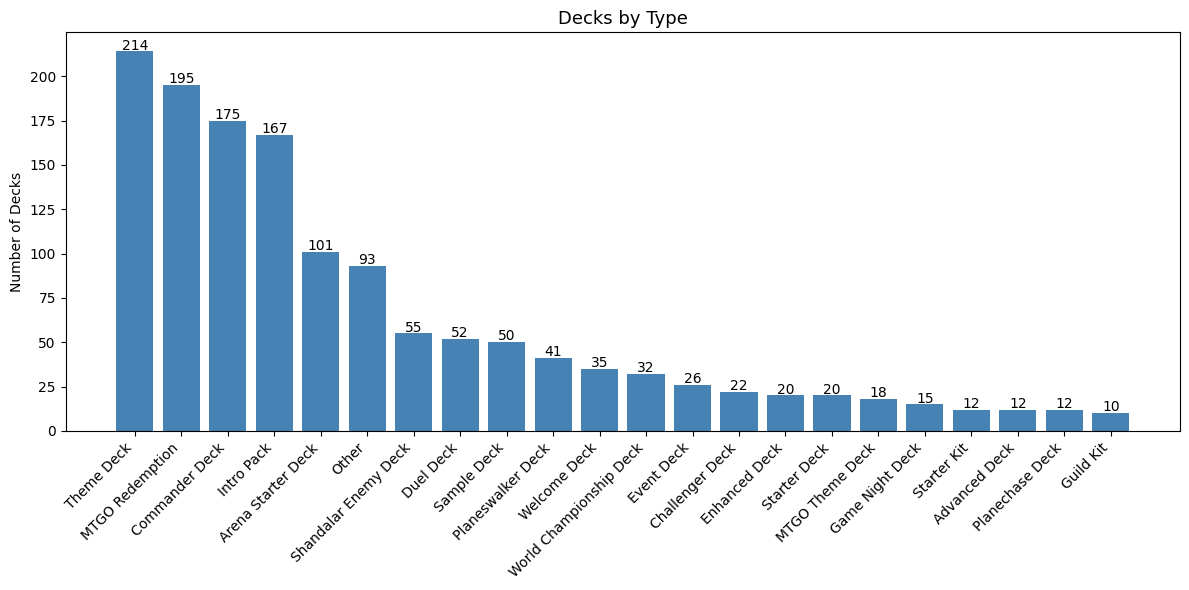

In [5]:
all_occurrences = [name for names in decks_df['card_names'] for name in names]
card_freq = Counter(all_occurrences)

print(f'Total decks:          {len(decks_df):,}')
print(f'Unique deck types:    {decks_df["deck_type"].nunique()}')
print(f'Color identities:     {decks_df["color_identity"].nunique()}')
print(f'Total card occurances: {len(all_occurrences):,}')
print(f'Unique card names:    {len(card_freq):,}')
print(f'Avg deck size:        {decks_df["deck_size"].mean():.1f} cards')
print(f'Min/Max deck size:    {decks_df["deck_size"].min()} / {decks_df["deck_size"].max()}')

type_counts = decks_df['deck_type'].value_counts()
type_counts_filtered = type_counts[type_counts >= 10]
other_count = type_counts[type_counts < 10].sum()
if other_count > 0:
    type_counts_filtered['Other'] = other_count
type_counts_filtered = type_counts_filtered.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(type_counts_filtered.index, type_counts_filtered.values, color='steelblue')
ax.set_title('Decks by Type', fontsize=13)
ax.set_ylabel('Number of Decks')
for i, v in enumerate(type_counts_filtered.values):
    ax.text(i, v + 1, str(v), ha='center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 2.2: Variety
What differnt deck formats are present and how many color combinations do we have?

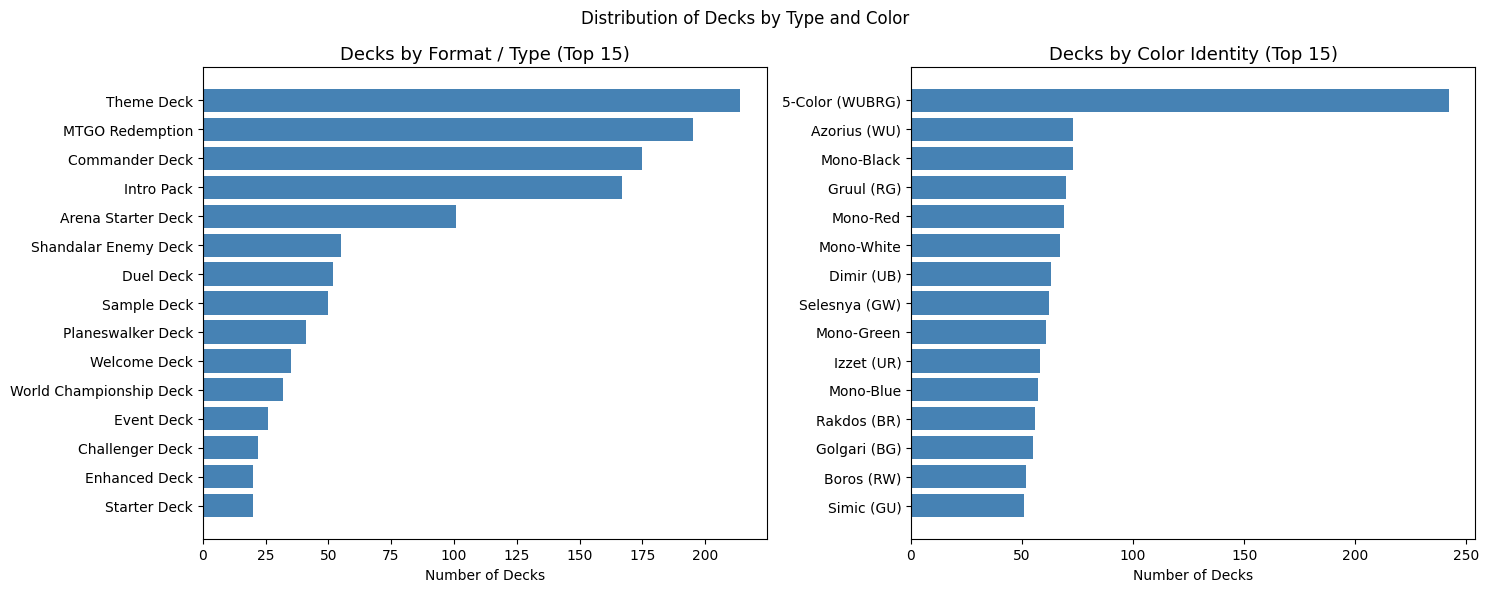

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

type_counts = decks_df['deck_type'].value_counts().head(15)
axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color='steelblue')
axes[0].set_title('Decks by Format / Type (Top 15)', fontsize=13)
axes[0].set_xlabel('Number of Decks')

color_counts = decks_df['color_identity'].value_counts().head(15)
axes[1].barh(color_counts.index[::-1], color_counts.values[::-1], color='steelblue')
axes[1].set_title('Decks by Color Identity (Top 15)', fontsize=13)
axes[1].set_xlabel('Number of Decks')

plt.suptitle('Distribution of Decks by Type and Color', fontsize=12)
plt.tight_layout()
plt.savefig('outputs\\eda_deck_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.3: Generaly Frequent Cards
What cards appear most often regardless of pairing, excluding basic lands?

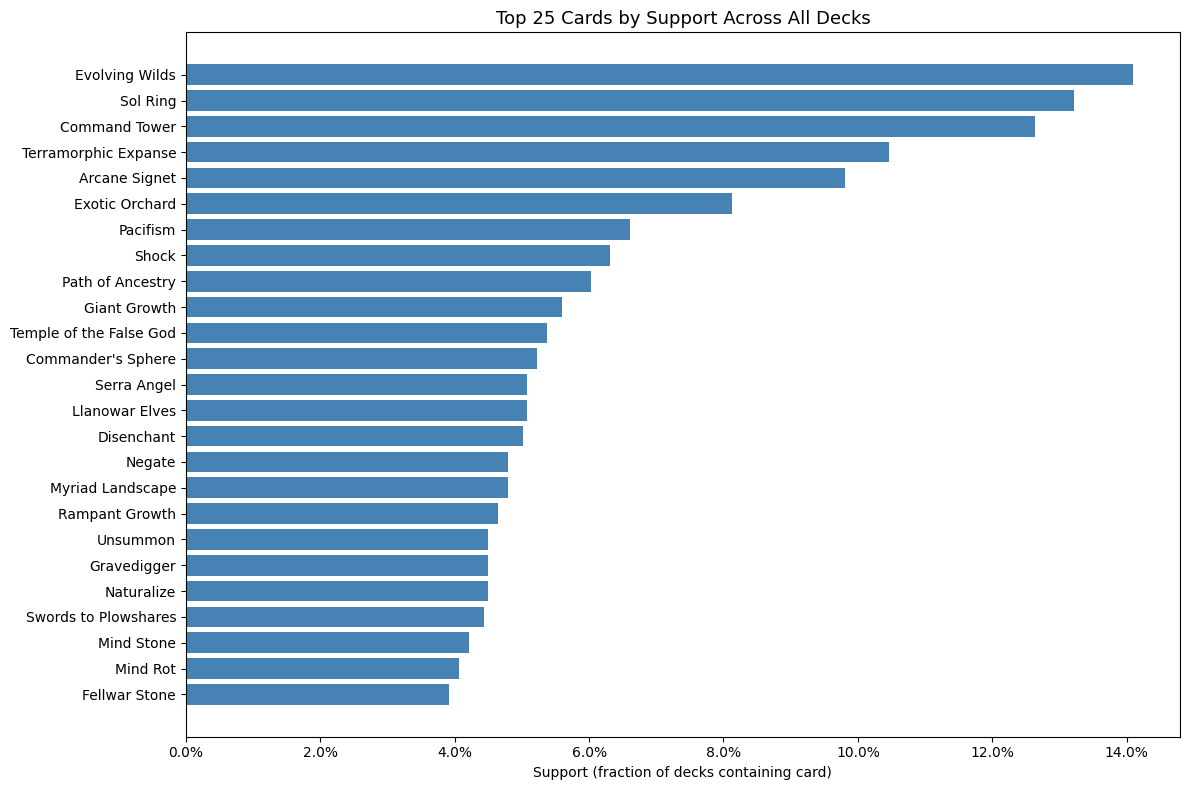

In [7]:
BASIC_LANDS = {'Plains', 'Island', 'Swamp', 'Mountain', 'Forest', 'Wastes', 'Snow-Covered Plains', 'Snow-Covered Island', 'Snow-Covered Swamp','Snow-Covered Mountain', 'Snow-Covered Forest'}

top_n = 25
top_cards = top_cards = pandas.DataFrame([(card, count) for card, count in card_freq.most_common() if card not in BASIC_LANDS],columns=['card', 'count']).head(top_n)
top_cards['support'] = top_cards['count'] / len(decks_df)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_cards['card'][::-1], top_cards['support'][::-1], color='steelblue')
ax.set_title(f'Top {top_n} Cards by Support Across All Decks', fontsize=13)
ax.set_xlabel('Support (fraction of decks containing card)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('outputs\\eda_top_cards_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2.4: Frequency of new releases
How many decks were released each year?

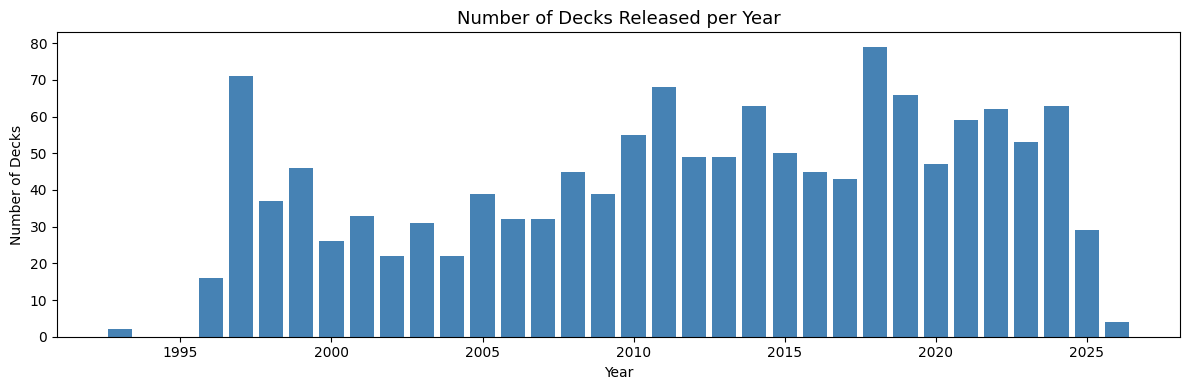

In [8]:
year_counts = decks_df['releaseYear'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_counts.index.astype(int), year_counts.values, color='steelblue')
ax.set_title('Number of Decks Released per Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Decks')
plt.tight_layout()
plt.savefig('outputs\\eda_decks_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.5: Sparsity Check
In order to determine our minimum support threshold we will examine the distribution of card frequencies.

Cards appearing in at least N decks:
  >=   1 decks (support >= 0.001): 25,213 cards (100.0% of unique cards)
  >=   2 decks (support >= 0.001): 21,006 cards (83.3% of unique cards)
  >=   5 decks (support >= 0.004): 3,643 cards (14.4% of unique cards)
  >=  10 decks (support >= 0.007):   873 cards (3.5% of unique cards)
  >=  20 decks (support >= 0.015):   247 cards (1.0% of unique cards)
  >=  50 decks (support >= 0.036):    33 cards (0.1% of unique cards)


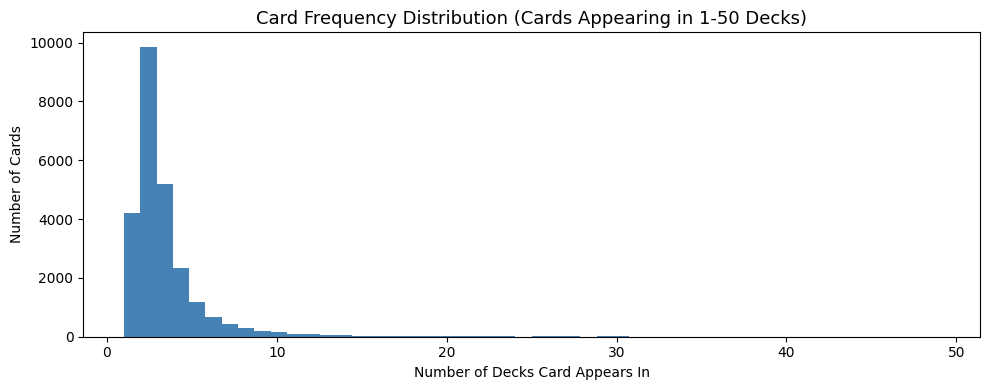

In [9]:
freq_values = list(card_freq.values())

thresholds = [1, 2, 5, 10, 20, 50]
print('Cards appearing in at least N decks:')
for t in thresholds:
    n = sum(1 for v in freq_values if v >= t)
    pct = n / len(card_freq) * 100
    support = t / len(decks_df)
    print(f'  >= {t:3d} decks (support >= {support:.3f}): {n:5,} cards ({pct:.1f}% of unique cards)')

fig, ax = plt.subplots(figsize=(10, 4))
filtered_freq = [v for v in freq_values if v <= 50]
ax.hist(filtered_freq, bins=50, color='steelblue')
ax.set_title('Card Frequency Distribution (Cards Appearing in 1-50 Decks)', fontsize=13)
ax.set_xlabel('Number of Decks Card Appears In')
ax.set_ylabel('Number of Cards')
plt.tight_layout()
plt.savefig('outputs\\eda_card_freq_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Preprocessing
**Decisions and rationale:**

1. Minimum deck size >= 20: Applied at load time. Removes incomplete/placeholder deck files and small collector's releases that would create noise without contributing real card co-occurrence data.

2. Remove basic lands: Plains, Island, Swamp, Mountain, Forest and their snow-covered variants are excluded from transactions as they will appear in most decks and generate technically real but useluss relationships.

3. Deduplicate card names per deck: A card appearing 4 times in a deck (e.g., in a 60-card format) is treated identically to one appearing once. We are mining for *presence*, not quantity.

In [10]:
def clean_transaction(names):
    return list(set(n for n in names if n not in BASIC_LANDS))

decks_df['transaction'] = decks_df['card_names'].apply(clean_transaction)
decks_df['transaction_size'] = decks_df['transaction'].apply(len)

print(f'Avg transaction size after cleaning: {decks_df["transaction_size"].mean():.1f} unique non-land cards')
print(f'Decks after preprocessing: {len(decks_df)}')

Avg transaction size after cleaning: 59.4 unique non-land cards
Decks after preprocessing: 1377


In [11]:
def encode_transactions(transaction_list):
    te = TransactionEncoder()
    te_array = te.fit(transaction_list).transform(transaction_list)
    return pandas.DataFrame(te_array, columns=te.columns_)

print('Encoding all transactions...')
te_df_all = encode_transactions(decks_df['transaction'].tolist())
sparsity = 1 - te_df_all.values.mean()
print(f'Encoded matrix: {te_df_all.shape[0]} decks x {te_df_all.shape[1]} unique cards')
print(f'Matrix sparsity: {sparsity:.1%} (most cells are False — expected for card data)')

Encoding all transactions...
Encoded matrix: 1377 decks x 25202 unique cards
Matrix sparsity: 99.8% (most cells are False — expected for card data)


## Step 4: Mining: Apriori + Association Rules

### Why Apriori?
Apriori is a well-established algorithm for problems like determining items in a cart that uses a bottom-up candidate generation approach. At our dataset size, runtime is not a concern so Apriori will work just as well as FP-Growth.

### Why Association Rules for this question?
Mainly because I was told I should focus on this in my feedback for M1. However, after seeing the relation ship between my problems and ones talked about in the reading, I see how the approach to this should be identical to the items in a cart problem.

### Old Threshold rationale (for M2)
- **min_support = 0.009** (0.9%): A card appearing in 12 of 1,377 decks is meaningfully recurring. The sparsity check above (Step 3.2) confirms this catches a useful number of cards without drowning in noise.
- **min_confidence = 0.40**: Given card X is in a deck, card Y appears 40%+ of the time. Balances interestingness with coverage.
- **lift > 1.1**: Filters rules that are only explained by each card's individual popularity — we want pairs co-occurring *more than chance would predict*.

### Updated Threshold rationale (for M3)
- **min_support = 0.02** - Raising the min support to 2% helps eliminate what I now identify as noise in the heatmap. 
- **min_confidence = 0.40**
- **lift > 2.0**

### Step 4.1: Global Patterns
In order to assure that are patterns for specific colors aren't echos of general popularity. We will need to see what cards occur frequently across color types.

In [12]:
MIN_SUPPORT    = 0.02
MIN_CONFIDENCE = 0.40
MIN_LIFT       = 2.0

min_count = int(MIN_SUPPORT * len(te_df_all))
frequent_cols = te_df_all.columns[te_df_all.sum() >= min_count]
te_df_filtered = te_df_all[frequent_cols]
print(f'Reduced matrix: {te_df_filtered.shape[0]} decks x {te_df_filtered.shape[1]} unique cards')
print(f'Filtered matrix columns: {te_df_filtered.shape[1]}')

print('Running Apriori on all decks...')
freq_items_all = apriori(te_df_filtered, min_support=MIN_SUPPORT, use_colnames=True)
freq_items_all = freq_items_all.sort_values('support', ascending=False)
print(f'Frequent itemsets found: {len(freq_items_all):,}')

rules_all = association_rules(freq_items_all, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules_all = rules_all[rules_all['lift'] >= MIN_LIFT].sort_values('lift', ascending=False)
print(f'Association rules found: {len(rules_all):,}')

# Preview top rules
display_rules = rules_all[['antecedents','consequents','support','confidence','lift']].copy()
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
display_rules.head(15)

Reduced matrix: 1377 decks x 112 unique cards
Filtered matrix columns: 112
Running Apriori on all decks...
Frequent itemsets found: 408
Association rules found: 1,905


,antecedents,consequents,support,confidence,lift
1880,"Arcane Signet, Command Tower, Sol Ring, Terram...","Evolving Wilds, Exotic Orchard",0.020334,0.700000,16.065000
1803,"Evolving Wilds, Exotic Orchard","Arcane Signet, Sol Ring, Terramorphic Expanse",0.020334,0.466667,16.065000
1795,"Arcane Signet, Sol Ring, Terramorphic Expanse","Evolving Wilds, Exotic Orchard",0.020334,0.700000,16.065000
1903,"Evolving Wilds, Exotic Orchard","Arcane Signet, Command Tower, Sol Ring, Terram...",0.020334,0.466667,16.065000
1892,"Arcane Signet, Sol Ring, Terramorphic Expanse","Command Tower, Evolving Wilds, Exotic Orchard",0.020334,0.700000,16.065000
1897,"Command Tower, Evolving Wilds, Exotic Orchard","Arcane Signet, Sol Ring, Terramorphic Expanse",0.020334,0.466667,16.065000
1888,"Arcane Signet, Evolving Wilds, Sol Ring","Command Tower, Exotic Orchard, Terramorphic Ex...",0.020334,0.509091,15.239526
1900,"Command Tower, Exotic Orchard, Terramorphic Ex...","Arcane Signet, Evolving Wilds, Sol Ring",0.020334,0.608696,15.239526
1742,"Commander's Sphere, Evolving Wilds","Sol Ring, Terramorphic Expanse",0.020334,0.800000,14.886486
1874,"Arcane Signet, Command Tower, Evolving Wilds, ...","Exotic Orchard, Terramorphic Expanse",0.020334,0.509091,14.604545


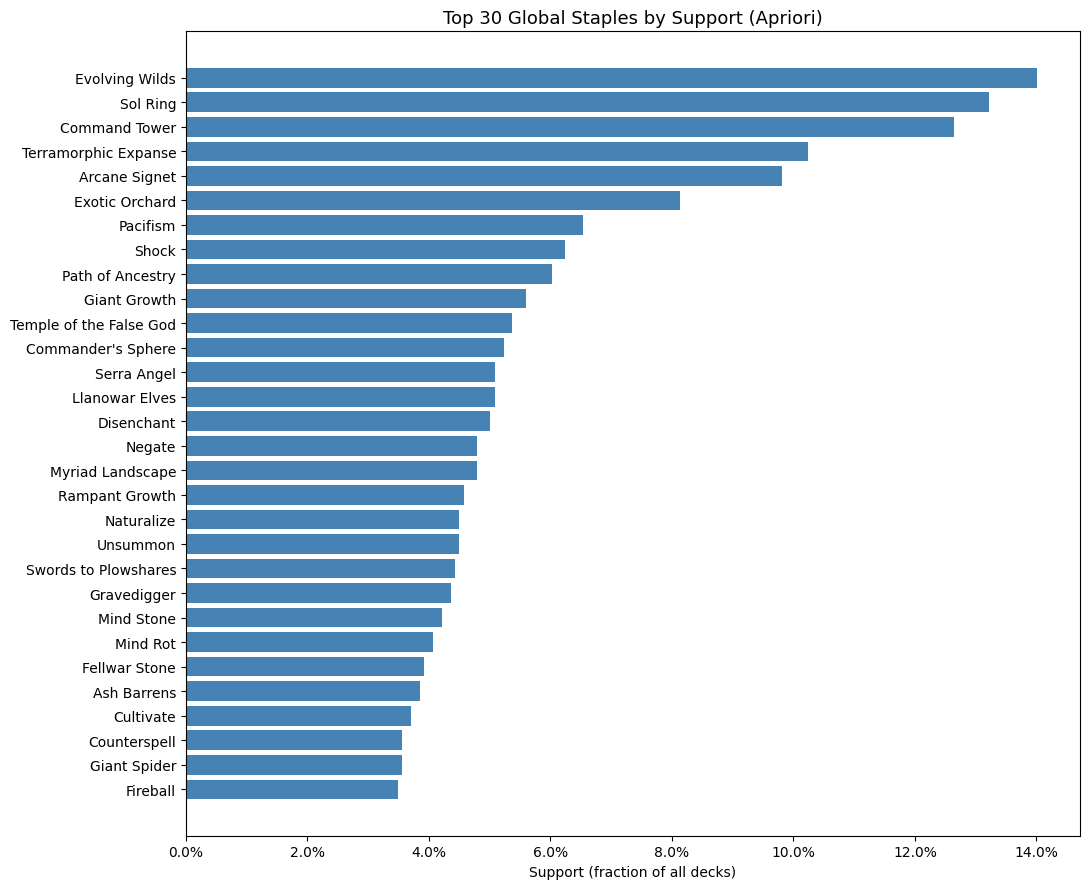

In [13]:
single_items = freq_items_all[freq_items_all['itemsets'].apply(lambda x: len(x) == 1)].copy()
single_items['card'] = single_items['itemsets'].apply(lambda x: list(x)[0])
top_staples = single_items.sort_values('support', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(top_staples['card'][::-1], top_staples['support'][::-1], color='steelblue')
ax.set_title('Top 30 Global Staples by Support (Apriori)', fontsize=13)
ax.set_xlabel('Support (fraction of all decks)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('outputs\\mining_global_staples.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4.2: Color Specifc

In [14]:
MIN_DECKS_PER_COLOR = 15

valid_colors = (
    decks_df['color_identity'].value_counts()
    .pipe(lambda s: s[s >= MIN_DECKS_PER_COLOR])
    .index.tolist()
)
print(f'Color groups with >= {MIN_DECKS_PER_COLOR} decks: {len(valid_colors)}')

color_staples = {}
color_rules   = {}

for color in valid_colors:
    subset = decks_df[decks_df['color_identity'] == color]
    transactions = subset['transaction'].tolist()
    n = len(transactions)

    # Use a slightly lower support floor for smaller color groups
    local_support = max(0.10, 5 / n)

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    te_df = pandas.DataFrame(te_array, columns=te.columns_)

    freq = apriori(te_df, min_support=local_support, use_colnames=True)
    if freq.empty:
        continue

    singles = freq[freq['itemsets'].apply(lambda x: len(x) == 1)].copy()
    singles['card'] = singles['itemsets'].apply(lambda x: list(x)[0])
    color_staples[color] = singles.sort_values('support', ascending=False).head(20)

    if len(freq) > 1:
        try:
            rules = association_rules(freq, metric='confidence', min_threshold=MIN_CONFIDENCE)
            rules = rules[rules['lift'] >= MIN_LIFT]
            color_rules[color] = rules.sort_values('lift', ascending=False)
        except Exception:
            pass

    print(f'{color:30s} | {n:4d} decks | {len(singles):4d} frequent cards | support >= {local_support:.2f}')

Color groups with >= 15 decks: 25
5-Color (WUBRG)                |  242 decks |   14 frequent cards | support >= 0.10
Azorius (WU)                   |   73 decks |    7 frequent cards | support >= 0.10
Mono-Black                     |   73 decks |   18 frequent cards | support >= 0.10
Gruul (RG)                     |   70 decks |    8 frequent cards | support >= 0.10
Mono-Red                       |   69 decks |   16 frequent cards | support >= 0.10
Mono-White                     |   67 decks |   10 frequent cards | support >= 0.10
Dimir (UB)                     |   63 decks |   11 frequent cards | support >= 0.10
Selesnya (GW)                  |   62 decks |   10 frequent cards | support >= 0.10
Mono-Green                     |   61 decks |   10 frequent cards | support >= 0.10
Izzet (UR)                     |   58 decks |   15 frequent cards | support >= 0.10
Mono-Blue                      |   57 decks |   16 frequent cards | support >= 0.10
Rakdos (BR)                    |   56 deck

#### Step 4.2.1 Visualization of Color Specific Mining
Charts are orderd top to bottom left to right for color groups with the lowest support to the highest

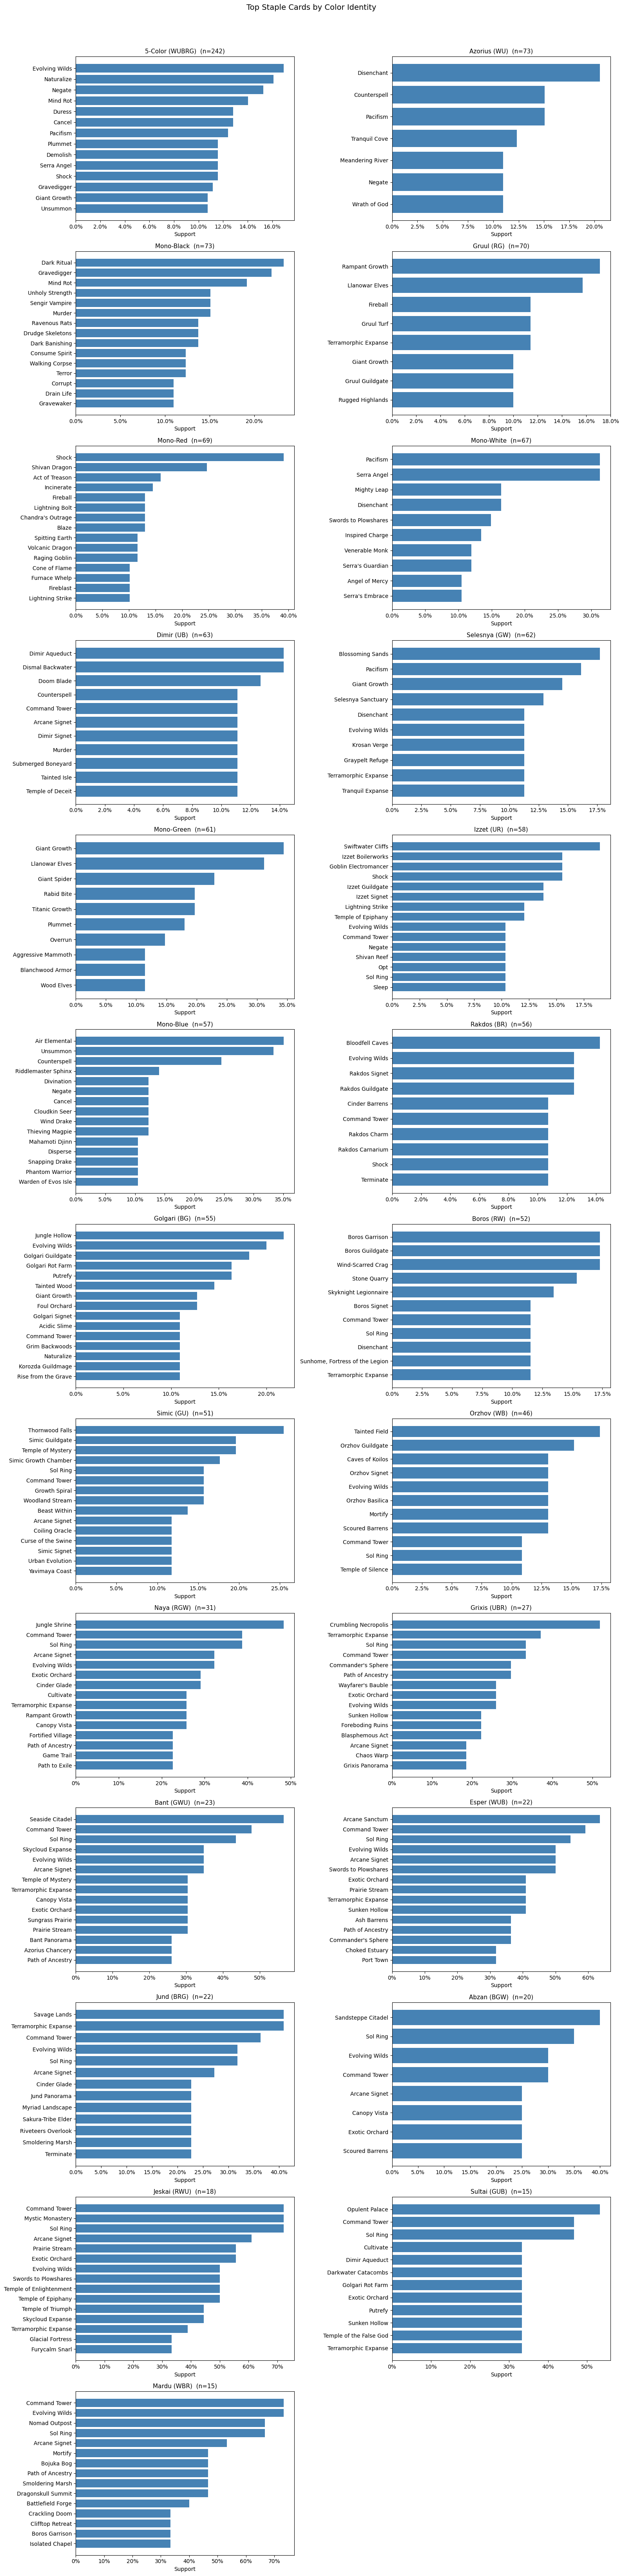

In [15]:
top_colors_to_plot = (
    decks_df['color_identity'].value_counts()
    .loc[lambda s: s.index.isin(color_staples.keys())]
    .index.tolist()[:25]
)

n_cols = 2
n_rows = (len(top_colors_to_plot) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, color in enumerate(top_colors_to_plot):
    df = color_staples[color].head(15)
    axes[i].barh(df['card'][::-1], df['support'][::-1], color='steelblue')
    n_decks = len(decks_df[decks_df['color_identity'] == color])
    axes[i].set_title(f'{color}  (n={n_decks})', fontsize=11)
    axes[i].set_xlabel('Support')
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for j in range(len(top_colors_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Staple Cards by Color Identity', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs\\mining_staples_by_color.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4.3 Heatmap for staples across group

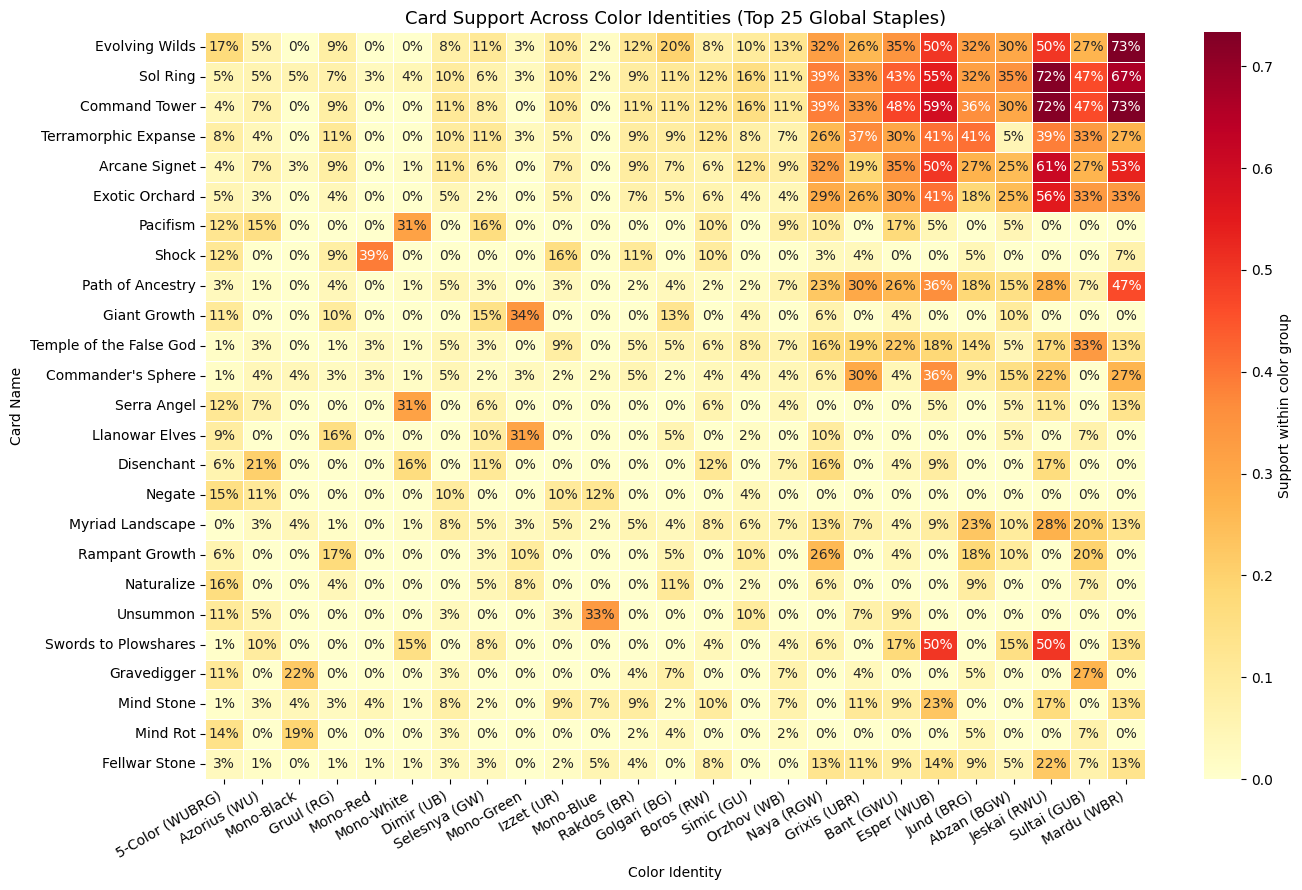

In [16]:
top_global_cards = top_staples['card'].tolist()[:25]

heatmap_data = {}
for color in top_colors_to_plot:
    subset = decks_df[decks_df['color_identity'] == color]
    n = len(subset)
    col_freq = Counter(name for names in subset['transaction'] for name in names)
    heatmap_data[color] = {card: col_freq.get(card, 0) / n for card in top_global_cards}

heatmap_df = pandas.DataFrame(heatmap_data, index=top_global_cards)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(heatmap_df, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Support within color group'})
ax.set_title('Card Support Across Color Identities (Top 25 Global Staples)', fontsize=13)
ax.set_xlabel('Color Identity')
ax.set_ylabel('Card Name')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs\\mining_staple_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Preliminary Findings

In [17]:
print('Universal Staples (support >= 10% across all decks):')
universal = single_items[single_items['support'] >= 0.10].sort_values('support', ascending=False)
print(universal[['card','support']].to_string(index=False))

print()
print('Color-Specific Staples (appear in top staples for only 1-2 color groups):')
card_color_count = Counter()
for color, df in color_staples.items():
    for card in df['card']:
        card_color_count[card] += 1

color_specific = [(card, cnt) for card, cnt in card_color_count.items() if cnt <= 2]
print(f'{len(color_specific)} cards appear as top staples in only 1-2 color groups.')
print('Examples:', [c for c,_ in color_specific[:10]])

Universal Staples (support >= 10% across all decks):
                card  support
      Evolving Wilds 0.140160
            Sol Ring 0.132171
       Command Tower 0.126362
Terramorphic Expanse 0.102397

Color-Specific Staples (appear in top staples for only 1-2 color groups):
189 cards appear as top staples in only 1-2 color groups.
Examples: ['Naturalize', 'Mind Rot', 'Duress', 'Cancel', 'Plummet', 'Demolish', 'Serra Angel', 'Gravedigger', 'Unsummon', 'Tranquil Cove']


## Interpretation
### Key Finding 1 — Universal staples are confirmed.
Cards like *Evolving Wilds*, *Sol Ring*, *Command Tower*, and *Terramorphic Expanse* appear across 10% of all decks, confirming community knowledge that certain cards are near-automatic inclusions. This finding makes sense, as these cards can provide signifigant benifit in any deck most decks they are put in. Additionally, most are limited to commander, explaining why they have such a low support despite being the highest support.

### Key Finding 2 — Color-specific staples are identifiable and meaningful for some colors but not all.
The per-color heatmap reveals cards that spike sharply in one color group but are absent from others. There are a few stand out cards with strong support for being paired with a specific color identity: *Shock* in Mono-Red at 39%, *Serra Angel* and *Pacifism* in Mono-White both at 31%, Strong ramp cards *Giant Growth* and *Llanowar Elves* in Mono-Green at 34% and 31% respectively, and most noteable *Swords to Plowshares* at 50% in both Esper (WUB) and Sultai (GUB)

### Key Finding 3
The five most popular cards: *Evolving Wilds*, *Sol Ring*, *Command Tower*, *Terramorphic Expanse*, *Arcane Signet*, and *Exotic Orchard* all have very high support > 25% in most 3 color combos. This makes sense as these cards all help with getting the desired color of mana, so would be noticably absent from the Mono-Color decks and scarcer in the Dual-Colored decks as the data shows.

## Surprises. 
*Swords to Plowshares* is suprisingly not the strongest supported card in Mono-White despite being supported heavily in Esper (WUB) and Sultai (GUB). This may show that the interests of a Mono-White player tend to lean away from the control elemetns that Esper (WUB) and Sultai (GUB) rely on.

*Unsummon* being of higher support than *Counterspell* is very suprising to me. Infact, the complete absence of *Counterspell* I find very interesting. Seeing as these are decks created by Wizards of the Coast, this may support evidence that they are trying to weed out occurances of *Counterspell* despite its strength and popularity.


**Limitations.**  
- Dataset is preconstructed official decks only; staples in competitive/casual will differ signifigantly. This data says more about what Wizards of the Coast envision their game to be than it does about what the game actually is. 
- This does not limit comparison within a specific play format, so data is generalized between formats like Commander, Standard, and Brawl.

## Step 6: Export DQ1 Results

In [18]:
rules_export = rules_all[['antecedents','consequents','support','confidence','lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules_export.to_csv('outputs\\top_association_rules.csv', index=False)

all_color_staples_rows = []
for color, df in color_staples.items():
    tmp = df[['card','support']].copy()
    tmp['color_identity'] = color
    all_color_staples_rows.append(tmp)
pandas.concat(all_color_staples_rows).to_csv('outputs\\staples_by_color.csv', index=False)

print('Exported: top_association_rules.csv, staples_by_color.csv')

Exported: top_association_rules.csv, staples_by_color.csv


# Discovery Question 2:
## *What 'staple' cards tend to be present in decks of the various play formats and across different eras?*

This question is very similar in form to the first, except it is concerned with patterns within a format rather than within a color combination. We can use the same technique as Discovery Question 1, Apriori Association Rules. Before we did this only once but for this question we will need to run: once for each format with enough presence in the deck, then once for each era.

## Step 7: Staples Across Format
The first step of the question is to identify what staples exist across various play formats

### Step 7.1: Which formats have enough data
Before we can seperate the data frame by deck type to analyze them individualy, we should first determine which formats are worth analyzing. Any format with a low presence in the data set( < 100 rows) or extremely low relevence to mainstream Magic the Gathering can be excluded. In section 2.2 we saw that only 5 formats have more than 100 decks in the data base: Theme Deck (214), MTGO Redeption (195), Commander Deck (175), Intro Pack (167), and Arena Starter Deck at (101).

In [19]:
MIN_DECKS_PER_FORMAT = 100

valid_formats = (
    decks_df['deck_type'].value_counts()
    .pipe(lambda s: s[s >= MIN_DECKS_PER_FORMAT])
    .index.tolist()
)
print(f'Formats with >= {MIN_DECKS_PER_FORMAT} decks: {len(valid_formats)}')
print(valid_formats)


Formats with >= 100 decks: 5
['Theme Deck', 'MTGO Redemption', 'Commander Deck', 'Intro Pack', 'Arena Starter Deck']


### Step 7.2: Appriori rounds 1 -5
We start by running appriori on our sub set of each of the valid formats. The starting values are unchanged from what was above but are changed from what was in the previous assignment based on feedback I recieved. However, in order to avoid memory allocation errors we use a dynamic support floor that slowly raised by 0.005. For that same reason we also have a max column cap of 500 and max length of 2 for combinations. 

In [20]:
MIN_SUPPORT    = 0.02
MIN_CONFIDENCE = 0.40
MIN_LIFT       = 2.0

format_staples = {}

for fmt in valid_formats:
    subset = decks_df[decks_df['deck_type'] == fmt]
    transactions = subset['transaction'].tolist()
    n = len(transactions)
    local_support = max(MIN_SUPPORT, 5 / n)

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    te_df = pandas.DataFrame(te_array, columns=te.columns_)

    # Pre-filter columns
    min_count = int(local_support * n)
    frequent_cols = te_df.columns[te_df.sum() >= min_count]
    te_df = te_df[frequent_cols]
    
    # Hard cap — if still too many columns raise support until under 500
    while te_df.shape[1] > 500:
        local_support += 0.005
        min_count = int(local_support * n)
        frequent_cols = te_df.columns[te_df.sum() >= min_count]
        te_df = te_df[frequent_cols]

    print(f'{fmt:40s} | {n:4d} decks | {te_df.shape[1]:4d} cols | support = {local_support:.3f}')

    freq = apriori(te_df, min_support=local_support, use_colnames=True, max_len=2)
    if freq.empty:
        continue

    singles = freq[freq['itemsets'].apply(lambda x: len(x) == 1)].copy()
    singles['card'] = singles['itemsets'].apply(lambda x: list(x)[0])
    format_staples[fmt] = singles.sort_values('support', ascending=False).head(20)

Theme Deck                               |  214 decks |   51 cols | support = 0.023
MTGO Redemption                          |  195 decks |  244 cols | support = 0.041
Commander Deck                           |  175 decks |  394 cols | support = 0.039
Intro Pack                               |  167 decks |   47 cols | support = 0.030
Arena Starter Deck                       |  101 decks |    9 cols | support = 0.050


### Step 7.3: Commander Dominated results for Top 20 Global Staples
We see that of the most frequently accuring cards the only format with any real support for them is commander. Additionally commander has extreme support at that. This is what we would expect to see knowing that in the other formats cards eventually age out, leading to a much wider pool than in the much more constant commander decks.

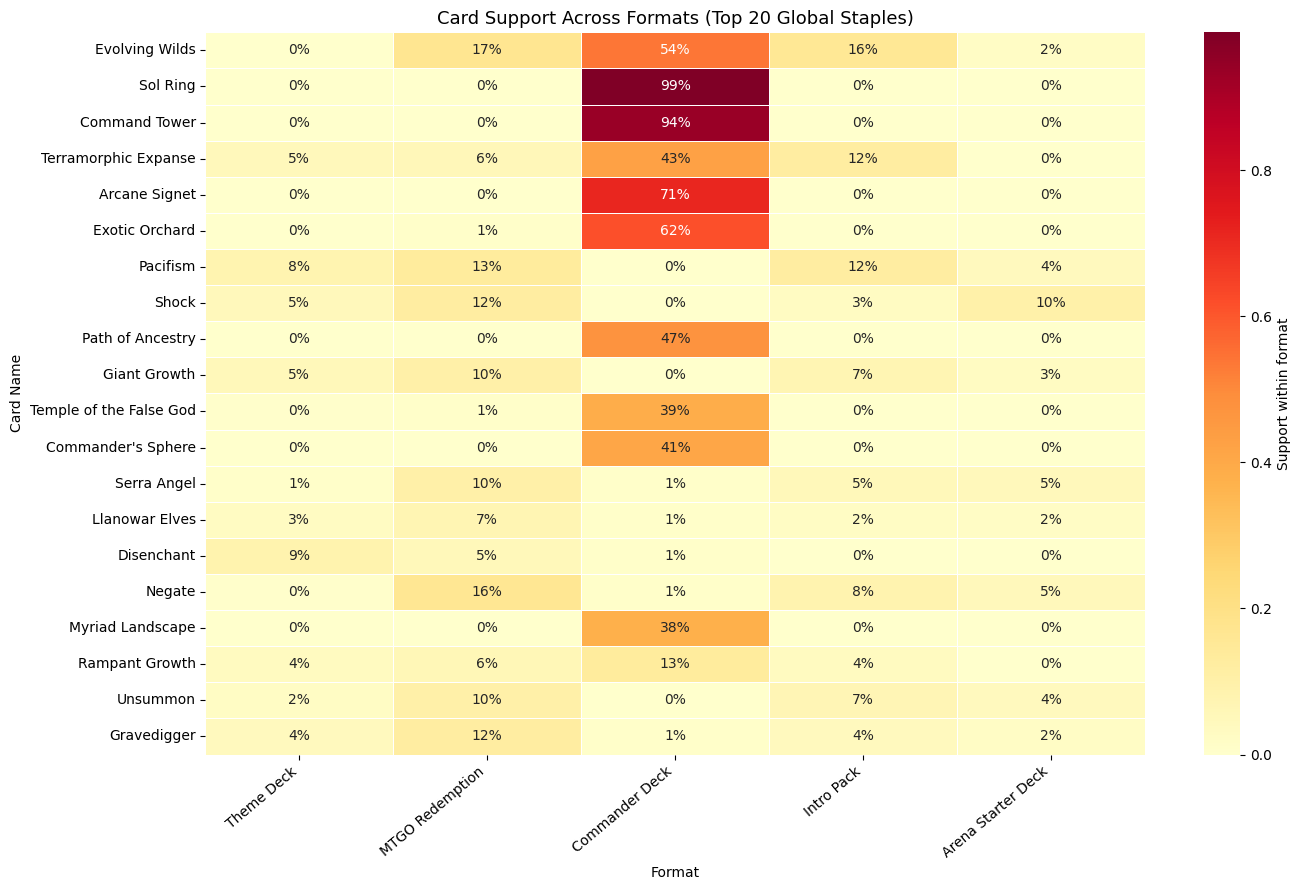

In [21]:
top_global_cards = (
    pandas.DataFrame(card_freq.most_common(), columns=['card','count'])
    .pipe(lambda df: df[~df['card'].isin(BASIC_LANDS)])
    .head(20)['card'].tolist()
)

heatmap_data = {}
for fmt in format_staples.keys():
    subset = decks_df[decks_df['deck_type'] == fmt]
    n = len(subset)
    col_freq = Counter(name for names in subset['transaction'] for name in names)
    heatmap_data[fmt] = {card: col_freq.get(card, 0) / n for card in top_global_cards}

heatmap_df = pandas.DataFrame(heatmap_data, index=top_global_cards)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(heatmap_df, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Support within format'})
ax.set_title('Card Support Across Formats (Top 20 Global Staples)', fontsize=13)
ax.set_xlabel('Format')
ax.set_ylabel('Card Name')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('outputs\\m3_staples_by_format.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 7.4: Format Specific Information
By seperating each format into each own graph we can get some results that are not dominated by the commander format. The Theme Deck and Arena Starter Deck formats still have some relatively low support, but we can still benefit from viewing what the highest support card is.

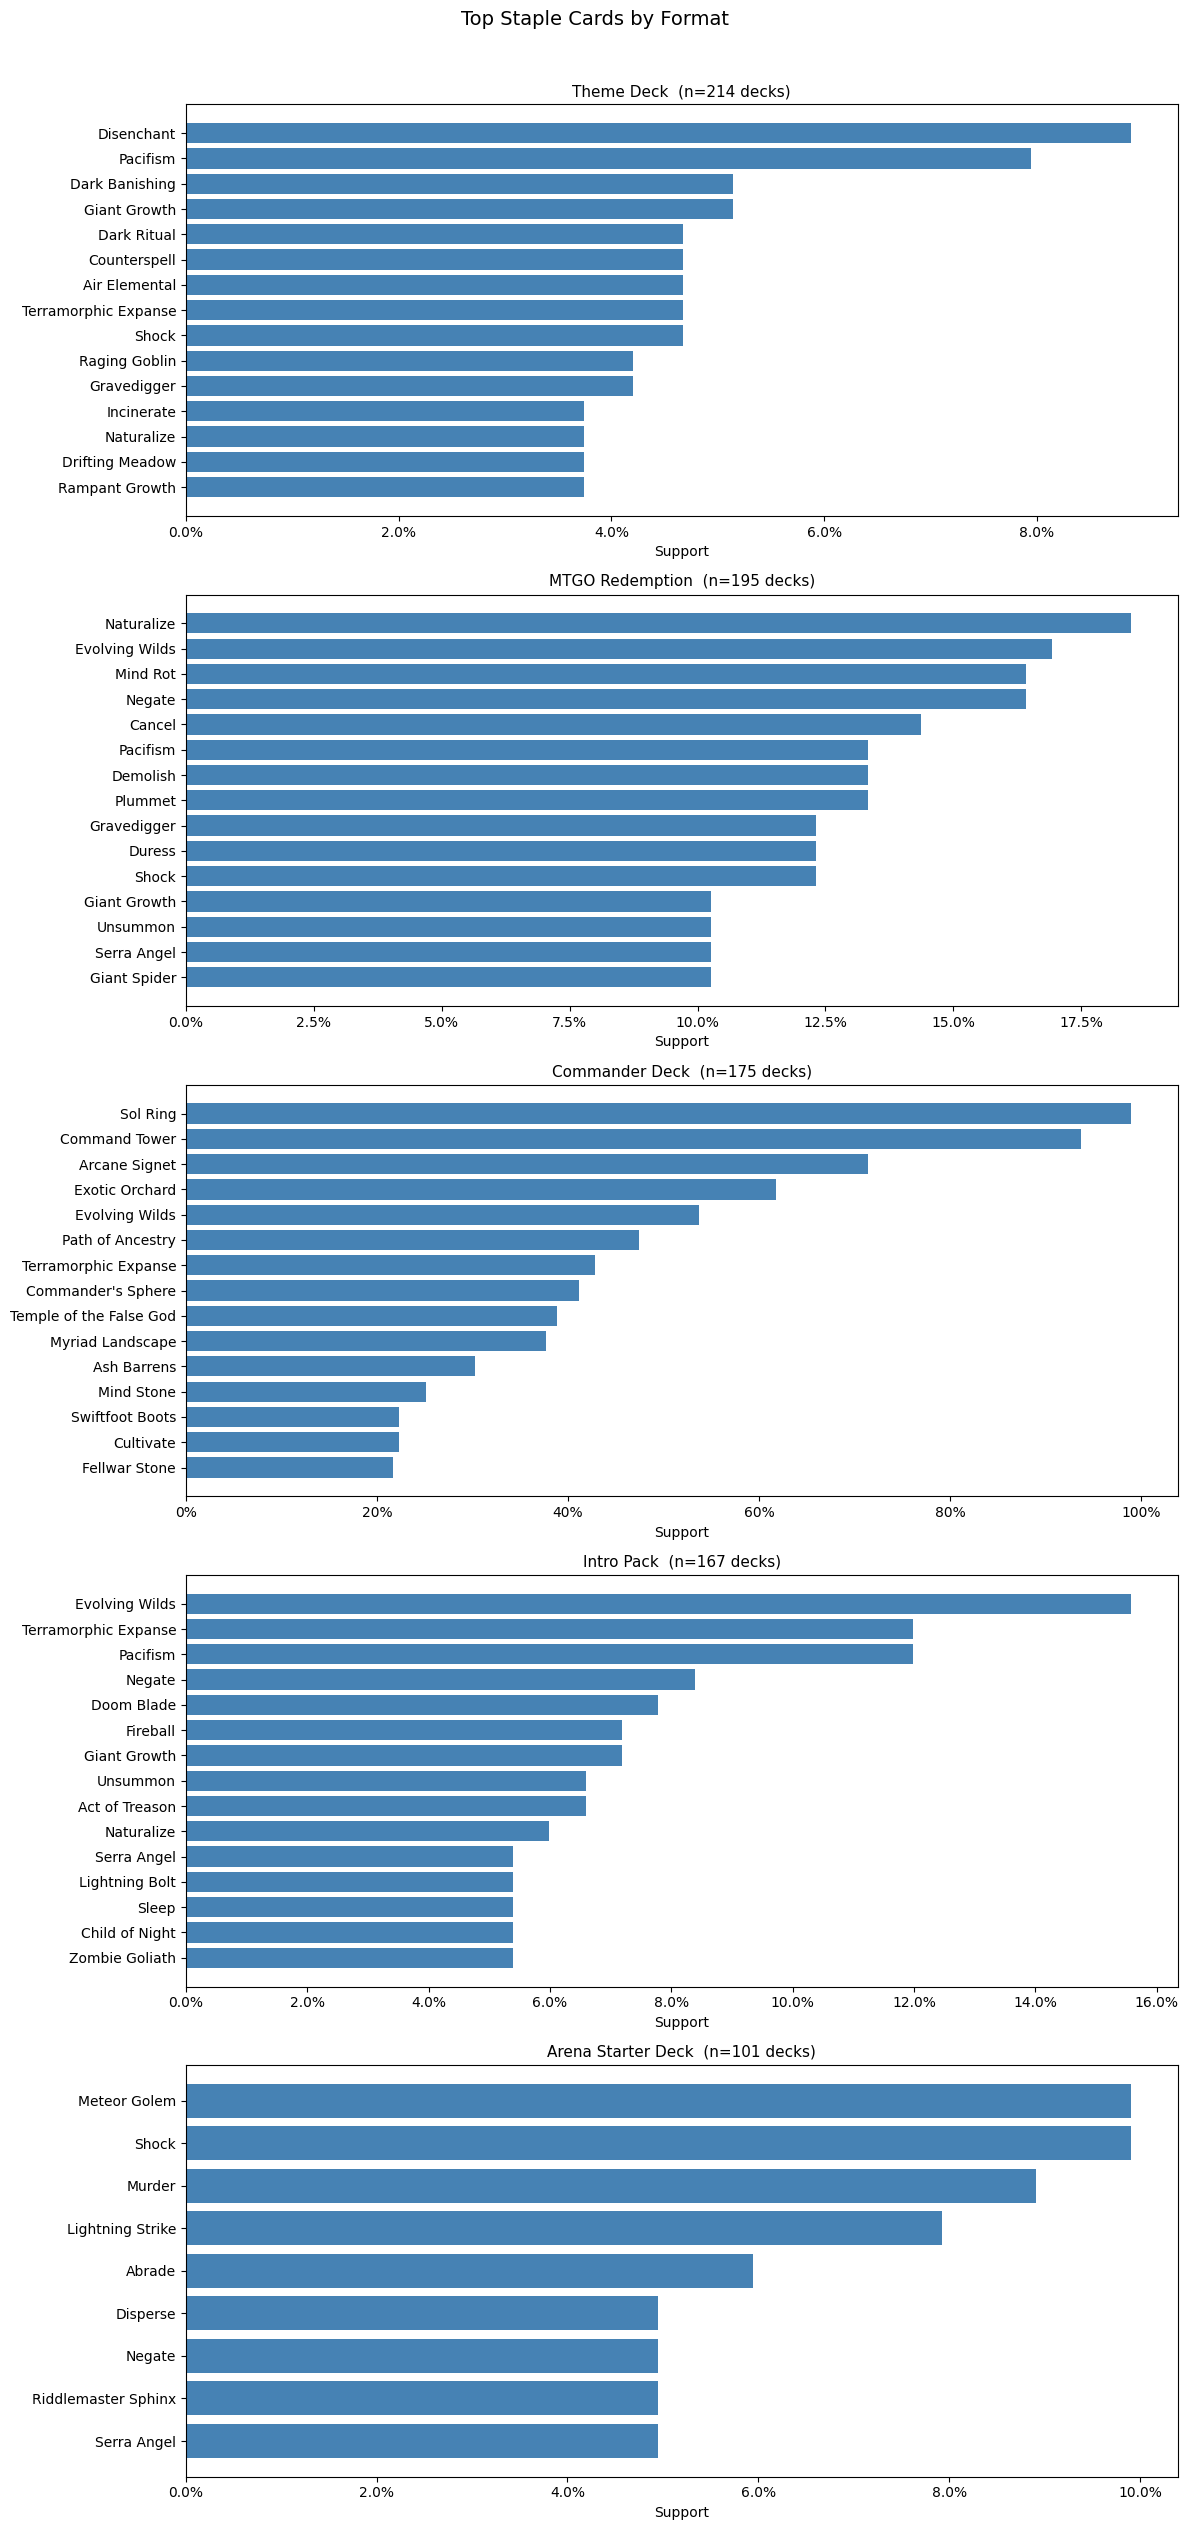

In [22]:
fig, axes = plt.subplots(len(format_staples), 1, figsize=(12, len(format_staples) * 5))

if len(format_staples) == 1:
    axes = [axes]

for i, (fmt, df) in enumerate(format_staples.items()):
    top = df.head(15)
    axes[i].barh(top['card'][::-1], top['support'][::-1], color='steelblue')
    n_decks = len(decks_df[decks_df['deck_type'] == fmt])
    axes[i].set_title(f'{fmt}  (n={n_decks} decks)', fontsize=11)
    axes[i].set_xlabel('Support')
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Top Staple Cards by Format', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs\\m3_staples_by_format_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Era specific data
Because the low support in non commander formats is likely due to the constantly changing pool of cards legal for use in other formats. This means we need to divide these formats by era and look for what patterns have existed in those eras rather than in total. We can create data for each era with all formats lumped together for analyzing global change over time, and then one for each era for each format given that there are > 15 decks for it.

In [23]:
ERA_ORDER = ['Pre-2015', '2015-2019', '2020-Present']
MIN_DECKS_PER_SLICE = 15

def assign_era(year):
    if pandas.isna(year):
        return None
    elif year < 2015:
        return 'Pre-2015'
    elif year <= 2019:
        return '2015-2019'
    else:
        return '2020-Present'

decks_df['era'] = decks_df['releaseYear'].apply(assign_era)
decks_df = decks_df[decks_df['era'].notna()]

era_counts = decks_df['era'].value_counts().reindex(ERA_ORDER)
print('Decks per era:')
print(era_counts.to_string())


era_staples = {}        # lumped time-only
format_era_staples = {} # format x era combined

for era in ERA_ORDER:
    era_subset = decks_df[decks_df['era'] == era]
    
    # ── Lumped time-only ──
    transactions = era_subset['transaction'].tolist()
    n = len(transactions)
    local_support = max(MIN_SUPPORT, 5 / n)

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    te_df = pandas.DataFrame(te_array, columns=te.columns_)

    while te_df.shape[1] > 150:
        local_support += 0.005
        min_count = int(local_support * n)
        te_df = te_df[te_df.columns[te_df.sum() >= min_count]]

    freq = apriori(te_df, min_support=local_support, use_colnames=True, max_len=2)
    if not freq.empty:
        singles = freq[freq['itemsets'].apply(lambda x: len(x) == 1)].copy()
        singles['card'] = singles['itemsets'].apply(lambda x: list(x)[0])
        era_staples[era] = singles.sort_values('support', ascending=False).head(20)
        print(f'[Lumped]  {era:20s} | {n:4d} decks | {te_df.shape[1]:4d} cols | support = {local_support:.3f}')

    # ── Format x era ──
    for fmt in valid_formats:
        slice_df = era_subset[era_subset['deck_type'] == fmt]
        n_slice = len(slice_df)

        if n_slice < MIN_DECKS_PER_SLICE:
            print(f'[Skipped] {fmt:30s} × {era:15s} | only {n_slice} decks')
            continue

        transactions = slice_df['transaction'].tolist()
        local_support = max(MIN_SUPPORT, 5 / n_slice)

        te = TransactionEncoder()
        te_array = te.fit(transactions).transform(transactions)
        te_df = pandas.DataFrame(te_array, columns=te.columns_)

        while te_df.shape[1] > 150:
            local_support += 0.005
            min_count = int(local_support * n_slice)
            te_df = te_df[te_df.columns[te_df.sum() >= min_count]]

        freq = apriori(te_df, min_support=local_support, use_colnames=True, max_len=2)
        if freq.empty:
            continue

        singles = freq[freq['itemsets'].apply(lambda x: len(x) == 1)].copy()
        singles['card'] = singles['itemsets'].apply(lambda x: list(x)[0])
        key = f'{fmt} × {era}'
        format_era_staples[key] = singles.sort_values('support', ascending=False).head(20)
        print(f'[Sliced]  {key:50s} | {n_slice:4d} decks | {te_df.shape[1]:4d} cols | support = {local_support:.3f}')

Decks per era:
era
Pre-2015        777
2015-2019       283
2020-Present    317
[Lumped]  Pre-2015             |  777 decks |   84 cols | support = 0.025
[Sliced]  Theme Deck × Pre-2015                              |  208 decks |   34 cols | support = 0.029
[Sliced]  MTGO Redemption × Pre-2015                         |  112 decks |   71 cols | support = 0.085
[Sliced]  Commander Deck × Pre-2015                          |   15 decks |   14 cols | support = 0.338
[Sliced]  Intro Pack × Pre-2015                              |  132 decks |   43 cols | support = 0.043
[Skipped] Arena Starter Deck             × Pre-2015        | only 0 decks
[Lumped]  2015-2019            |  283 decks |  126 cols | support = 0.030
[Skipped] Theme Deck                     × 2015-2019       | only 4 decks
[Sliced]  MTGO Redemption × 2015-2019                        |   40 decks |   35 cols | support = 0.130
[Sliced]  Commander Deck × 2015-2019                         |   30 decks |   53 cols | support = 0.172
[

### Step 8.1: Lumped Era Data
The lumped era data is good for showing us changes in the game in general. Howver, because of are results in the format specific data it can actually tell us something very interesting about commander. We saw earlier that commander decks had very high support for cards like *Sol Ring*, *Arcane Signet*, and *Command Tower* and that the other formats had very low support. We see in the bellow heatmap that those same cards become way more frequent as time passes. This can tell us that commander is becoming a drastically more popular product for Wizards of the Coast to produce over time.

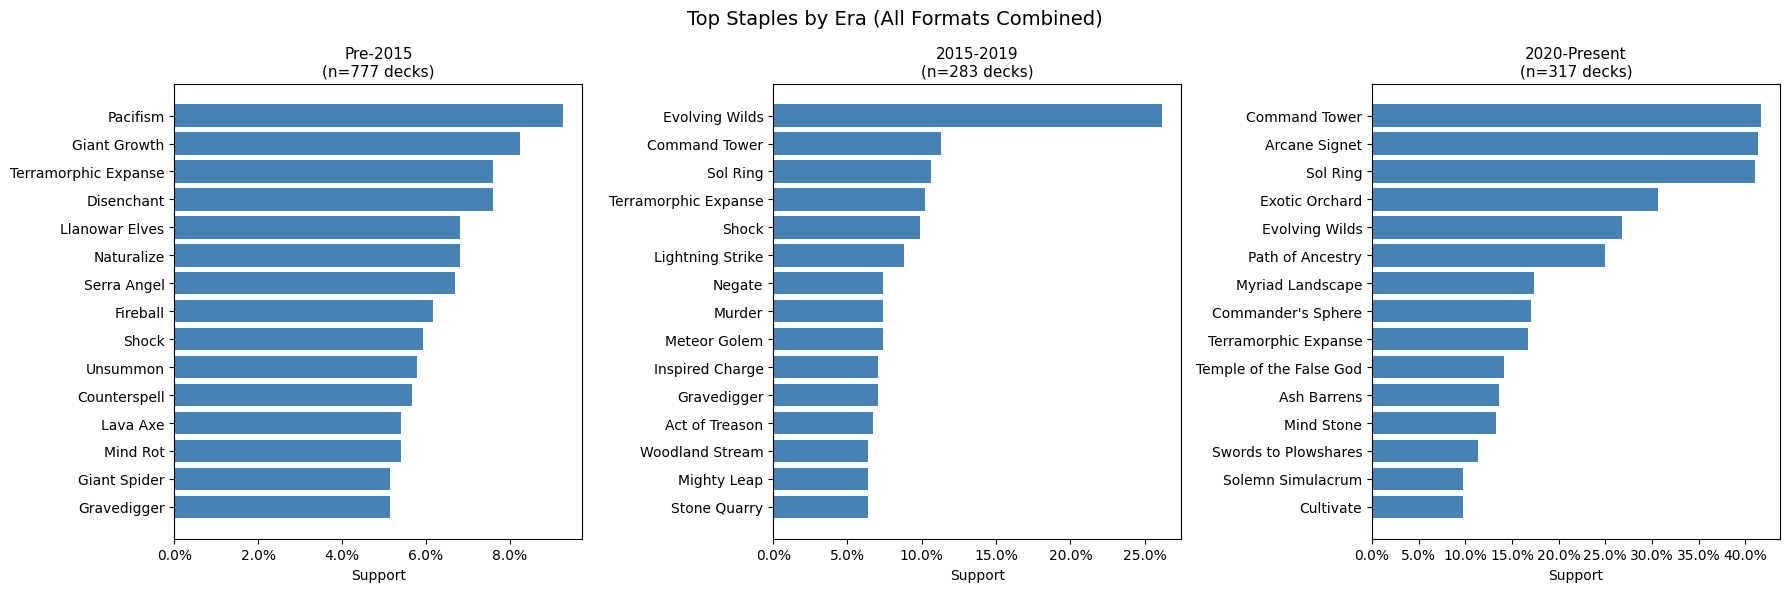

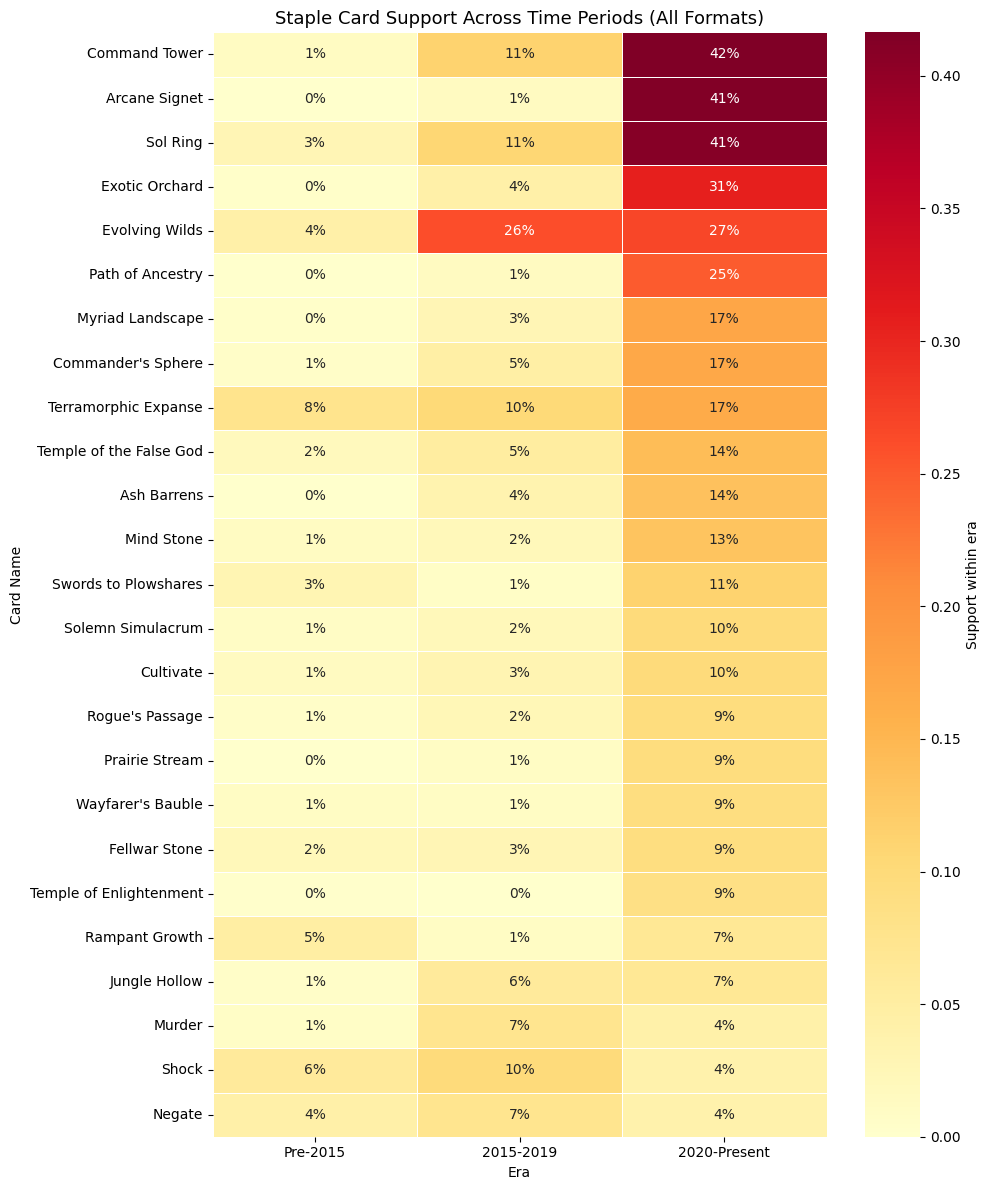

In [24]:
# 1. Lumped time-only bar charts
fig, axes = plt.subplots(1, len(era_staples), figsize=(18, 6))

for i, era in enumerate(ERA_ORDER):
    if era not in era_staples:
        continue
    df = era_staples[era].head(15)
    axes[i].barh(df['card'][::-1], df['support'][::-1], color='steelblue')
    n_decks = len(decks_df[decks_df['era'] == era])
    axes[i].set_title(f'{era}\n(n={n_decks} decks)', fontsize=11)
    axes[i].set_xlabel('Support')
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Top Staples by Era (All Formats Combined)', fontsize=14)
plt.tight_layout()
plt.savefig('outputs\\m3_staples_by_era_lumped.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Lumped time-only heatmap
all_era_cards = set()
for df in era_staples.values():
    all_era_cards.update(df['card'].tolist())
all_era_cards = list(all_era_cards)

heatmap_data = {}
for era in ERA_ORDER:
    if era not in era_staples:
        continue
    subset = decks_df[decks_df['era'] == era]
    n = len(subset)
    col_freq = Counter(name for names in subset['transaction'] for name in names)
    heatmap_data[era] = {card: col_freq.get(card, 0) / n for card in all_era_cards}

heatmap_df = pandas.DataFrame(heatmap_data, index=all_era_cards)
heatmap_df = heatmap_df.sort_values('2020-Present', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(heatmap_df, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Support within era'})
ax.set_title('Staple Card Support Across Time Periods (All Formats)', fontsize=13)
ax.set_xlabel('Era')
ax.set_ylabel('Card Name')
plt.tight_layout()
plt.savefig('outputs\\m3_staples_by_era_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 8.2: Format x era Data
This data provides us with three interesting findings about deck change over time:

1. MTGO Redemption seems to get more structured as time passes, with the same cards becoming drastically more supported each era. However, this could very likely be the result of having fewer decks realeasing for the format as time goes on.
2. Intro packs see a drastic rise in the presence of *Evolving Wilds* between the pre-2015 era and the 2015 - 2019 era.
3. Commander sees a very interesting spike in support for the land fixing cards *Terramorphic Expanse* and *Evolving Wilds* in the 2015 - 2019 era. This could suggest that this era had many powerful 3+ color decks that required good mana fixing. However, there is also a climb in the use of many other mana fixing tools that outlive those two. It may be possible that the community just began to favor other mana fixing tools over these ones.


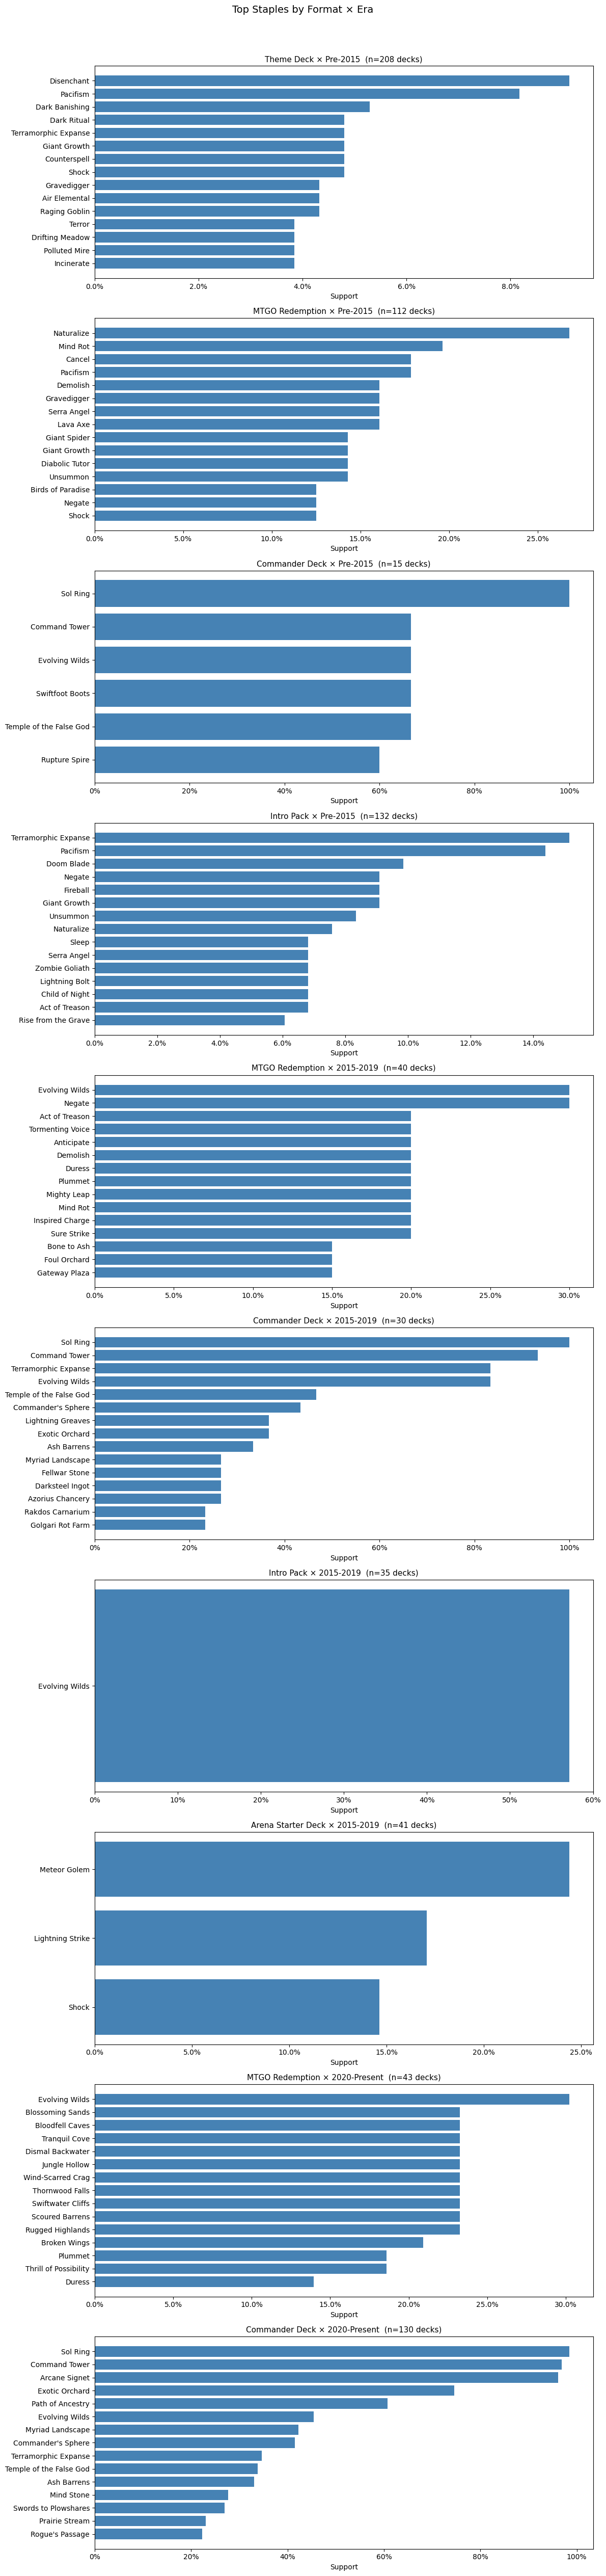

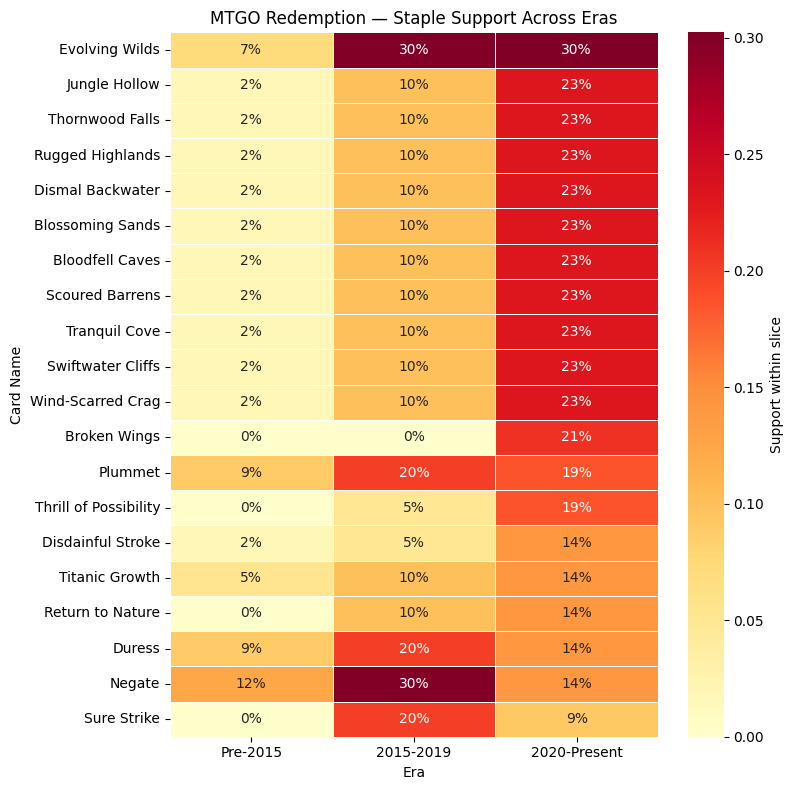

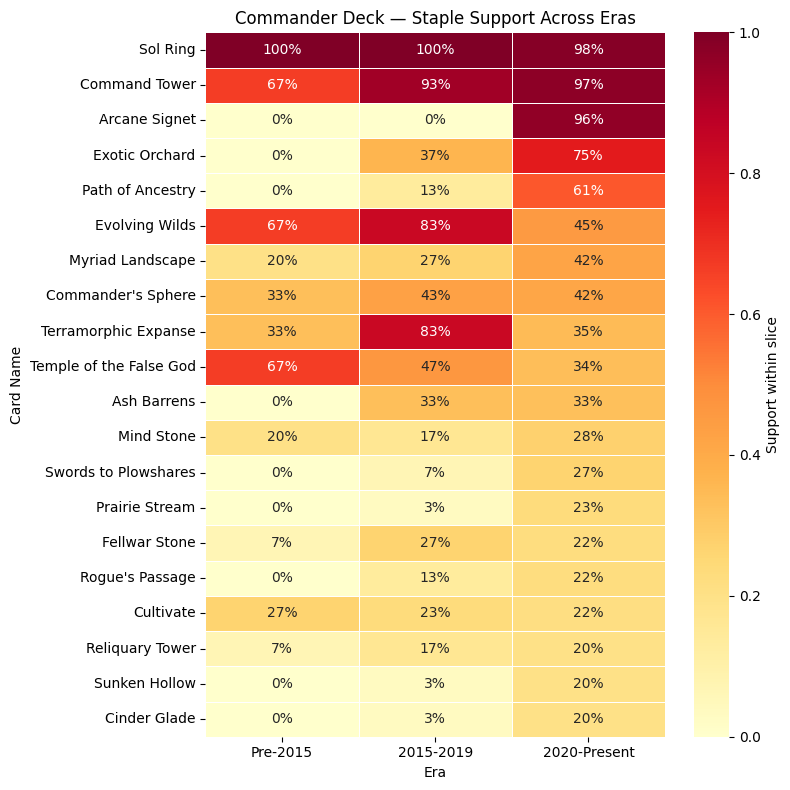

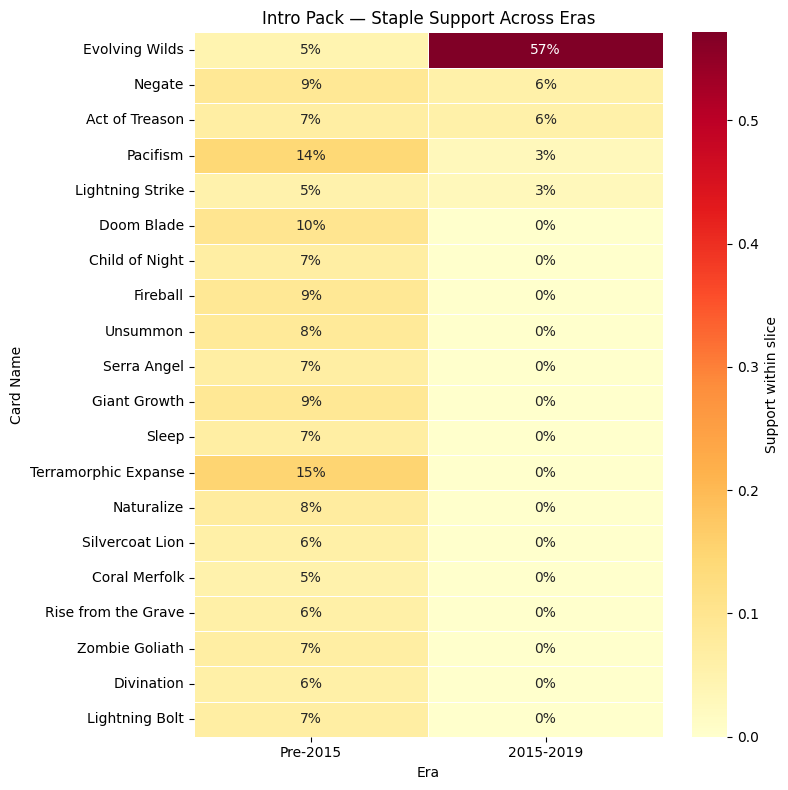

In [25]:
# 1. Format x era bar charts — one subplot per valid slice
slices = list(format_era_staples.keys())
n_slices = len(slices)
fig, axes = plt.subplots(n_slices, 1, figsize=(12, n_slices * 5))
if n_slices == 1:
    axes = [axes]

for i, key in enumerate(slices):
    df = format_era_staples[key].head(15)
    axes[i].barh(df['card'][::-1], df['support'][::-1], color='steelblue')
    n_decks = len(decks_df[
        (decks_df['deck_type'] == key.split(' × ')[0]) &
        (decks_df['era'] == key.split(' × ')[1])
    ])
    axes[i].set_title(f'{key}  (n={n_decks} decks)', fontsize=11)
    axes[i].set_xlabel('Support')
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Top Staples by Format × Era', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs\\m3_staples_format_era_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Format x era heatmap — for each format show support across its valid eras
for fmt in valid_formats:
    fmt_keys = [k for k in format_era_staples.keys() if k.startswith(fmt)]
    if len(fmt_keys) < 2:
        continue

    all_fmt_cards = set()
    for k in fmt_keys:
        all_fmt_cards.update(format_era_staples[k]['card'].tolist())
    all_fmt_cards = list(all_fmt_cards)

    hm_data = {}
    for k in fmt_keys:
        era = k.split(' × ')[1]
        subset = decks_df[(decks_df['deck_type'] == fmt) & (decks_df['era'] == era)]
        n = len(subset)
        cf = Counter(name for names in subset['transaction'] for name in names)
        hm_data[era] = {card: cf.get(card, 0) / n for card in all_fmt_cards}

    hm_df = pandas.DataFrame(hm_data, index=all_fmt_cards)
    # Sort by most recent era
    sort_col = [c for c in ERA_ORDER if c in hm_df.columns][-1]
    hm_df = hm_df.sort_values(sort_col, ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(hm_df, annot=True, fmt='.0%', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Support within slice'})
    ax.set_title(f'{fmt} — Staple Support Across Eras', fontsize=12)
    ax.set_xlabel('Era')
    ax.set_ylabel('Card Name')
    plt.tight_layout()
    fname = fmt.replace(' ', '_').replace('/', '_')
    plt.savefig(f'outputs\\m3_{fname}_era_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## Step 8.3 Export DQ2

In [26]:
all_format_staples_rows = []
for fmt, df in format_staples.items():
    tmp = df[['card', 'support']].copy()
    tmp['format'] = fmt
    all_format_staples_rows.append(tmp)
pandas.concat(all_format_staples_rows).to_csv('outputs\\staples_by_format.csv', index=False)

# Era staples (lumped)
all_era_staples_rows = []
for era, df in era_staples.items():
    tmp = df[['card', 'support']].copy()
    tmp['era'] = era
    all_era_staples_rows.append(tmp)
pandas.concat(all_era_staples_rows).to_csv('outputs\\staples_by_era.csv', index=False)

# Format x era cross-segment
all_format_era_rows = []
for key, df in format_era_staples.items():
    tmp = df[['card', 'support']].copy()
    tmp['format_era'] = key
    all_format_era_rows.append(tmp)
pandas.concat(all_format_era_rows).to_csv('outputs\\staples_by_format_era.csv', index=False)

print('Exported: staples_by_format.csv, staples_by_era.csv, staples_by_format_era.csv')

Exported: staples_by_format.csv, staples_by_era.csv, staples_by_format_era.csv


# Discovery Question 3:
## *What distinct deck construction patterns exist across different time periods and formats?*

The difference between  this question and the last is rather subtle. Where the last question was focused on discovering 'staple' cards, this question is focused on the overall similarity of different decks. Since the task is now aimed towards comparing decks to see paterns in construction rather than just identifying frequent occurances, this is well suited for K-Means Clustering. Afterwards we will use a decision tree to interpret the K-Means findings.

## Step 9: K-Means and Decision Tree

### Step 9.1: Re-Encode the transaction list to work for K-Means

In [27]:
print('Building card-presence matrix...')
transactions = decks_df['transaction'].tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
te_df_cluster = pandas.DataFrame(te_array, columns=te.columns_)

# Pre-filter to only frequent cards to keep matrix manageable
min_count = int(MIN_SUPPORT * len(te_df_cluster))
frequent_cols = te_df_cluster.columns[te_df_cluster.sum() >= min_count]
te_df_cluster = te_df_cluster[frequent_cols]

print(f'Matrix shape: {te_df_cluster.shape[0]} decks x {te_df_cluster.shape[1]} cards')

Building card-presence matrix...
Matrix shape: 1377 decks x 112 cards


### Step 9.2: Elbow Plot
In order to decide the k means, we'll generate an elbow plot of inertia over differnt values of k and choose the value at an elbow. There is no clear elbow here because of the small size of the data set, but 4 has the sharpest change so we will use that.

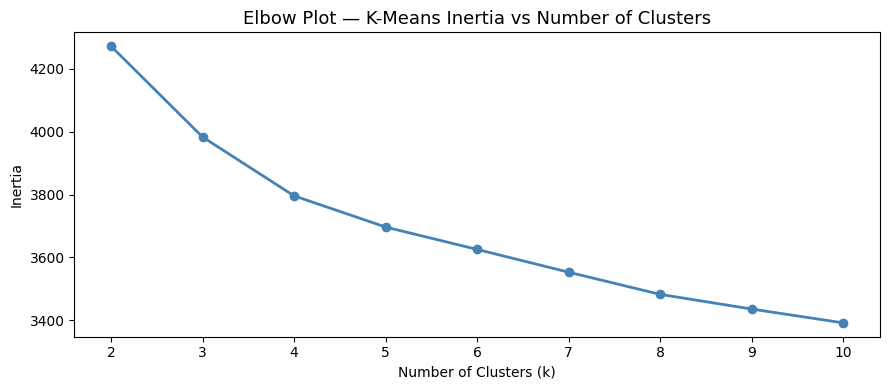

In [28]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(te_df_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Plot — K-Means Inertia vs Number of Clusters', fontsize=13)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('outputs\\m3_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Silhouette analysis across k=2–10
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(te_df_cluster)
    score = silhouette_score(te_df_cluster, labels, metric='euclidean', sample_size=500, random_state=42)
    sil_scores.append(score)
    print(f"k={k}  silhouette={score:.4f}")

k=2  silhouette=0.4392
k=3  silhouette=0.4481
k=4  silhouette=0.4545
k=5  silhouette=0.4393
k=6  silhouette=0.2156
k=7  silhouette=0.1532
k=8  silhouette=0.2197
k=9  silhouette=0.1538
k=10  silhouette=0.1526


## Step 9.2.1 Silhoutte Analysis
To further check that the choice in k is correct, silhouette anlaysis will be sued to analyze the best scores. We see that any choice and the first four would be accepatable but that 4 is clearly the winner and that naything past 5 would be unusable.

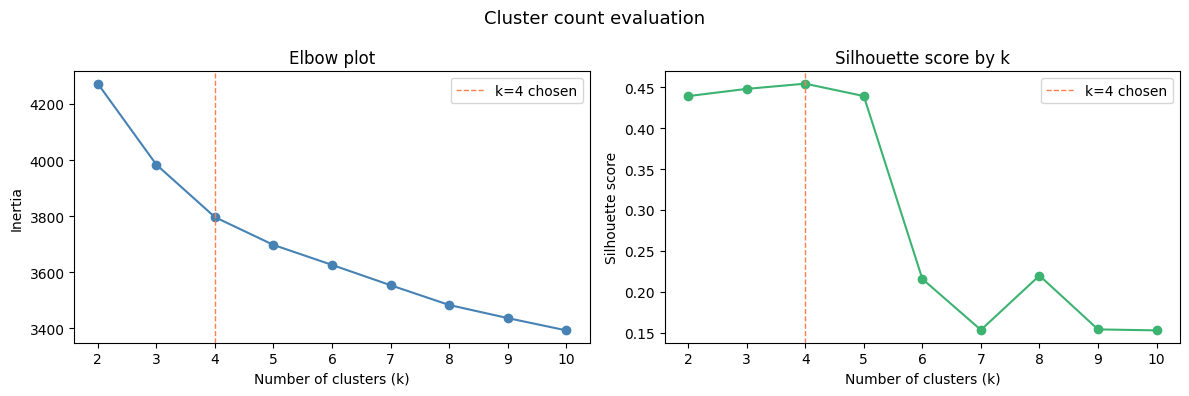

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(te_df_cluster)
    inertias.append(km.inertia_)

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=1.5)
axes[0].axvline(x=4, color='coral', linestyle='--', linewidth=1, label='k=4 chosen')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow plot')
axes[0].legend()

# Silhouette plot (new)
axes[1].plot(list(k_range), sil_scores, marker='o', color='mediumseagreen', linewidth=1.5)
axes[1].axvline(x=4, color='coral', linestyle='--', linewidth=1, label='k=4 chosen')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score by k')
axes[1].legend()

plt.suptitle('Cluster count evaluation', fontsize=13)
plt.tight_layout()
plt.savefig('outputs\\m4_cluster_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 9.3: Running K-Means and Interpreting Clusters with a Decision Tree
Unsurprisingly, *Command Tower* is by far the most descriminating card. This is another example of the strong commander bias in most of the findings so far. This is the culprit for the clear split off of commanderr cards from the general pool which makes sense as the card is only usable in commander and lets us split or decision tree in half with commander relavent information on the left and non commander on the right. 


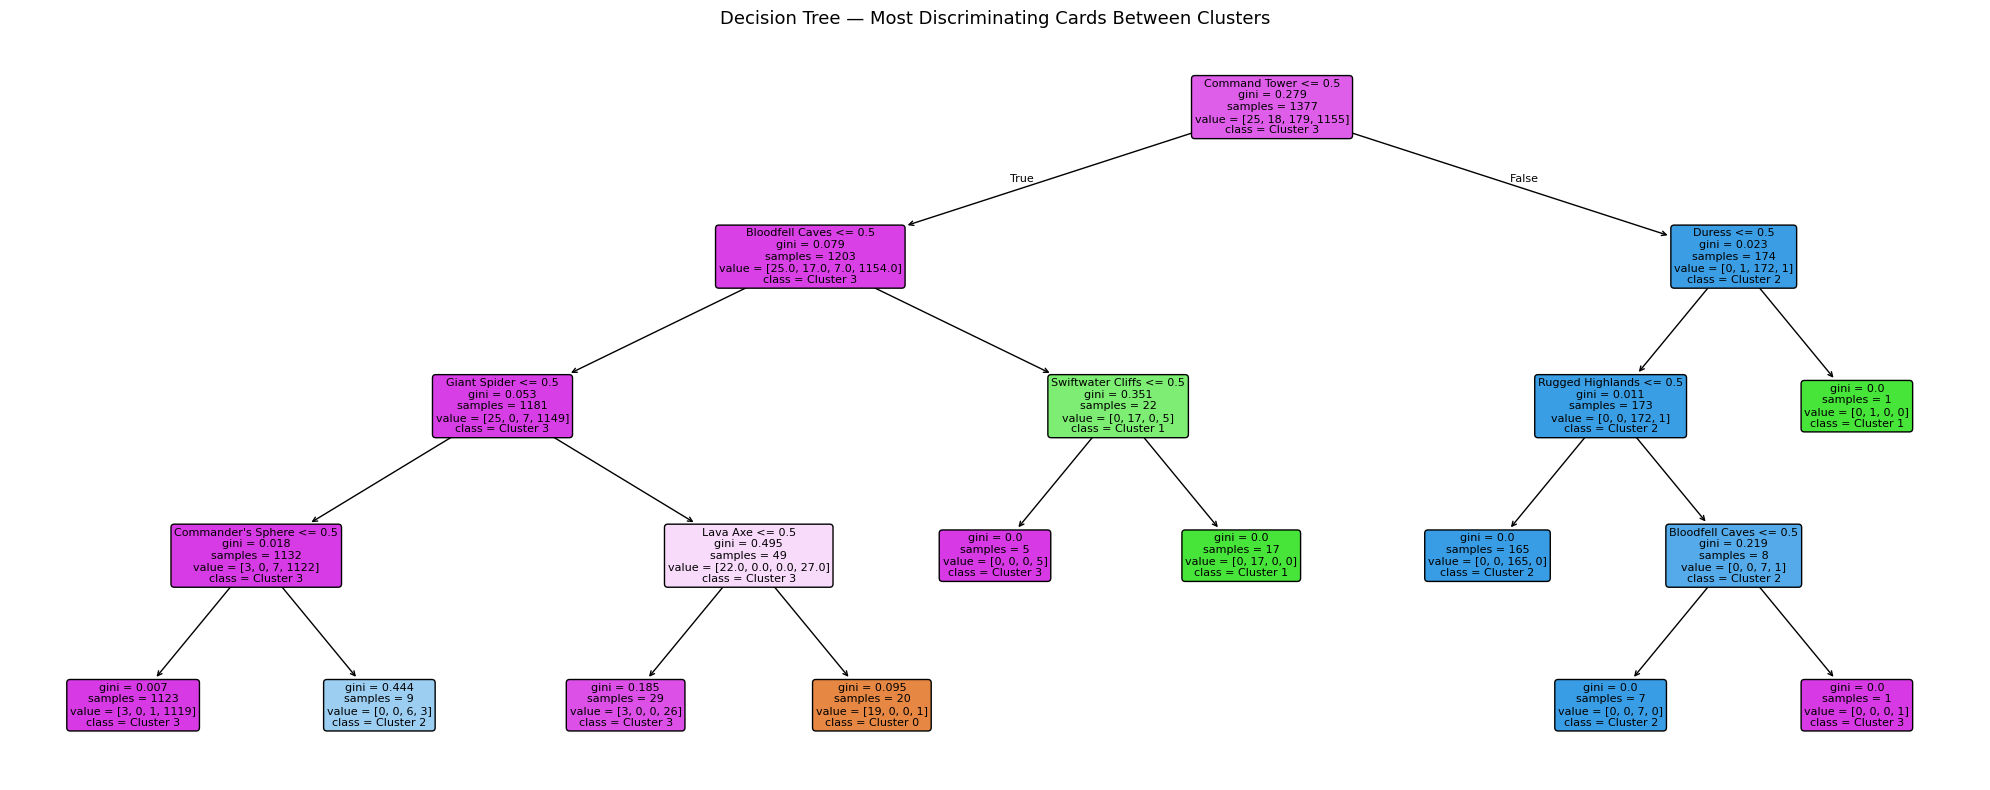

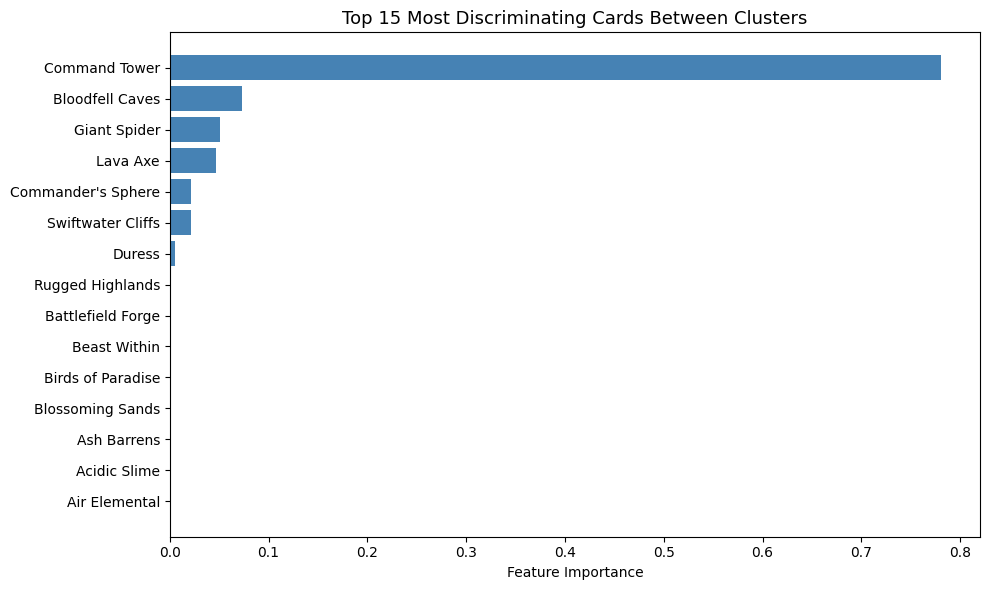

In [31]:
K = 4

km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km.fit_predict(te_df_cluster)
decks_df['cluster'] = cluster_labels

# Decision tree — explains cluster boundaries
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(te_df_cluster, cluster_labels)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=te_df_cluster.columns.tolist(),
          class_names=[f'Cluster {k}' for k in range(K)],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Most Discriminating Cards Between Clusters', fontsize=13)
plt.tight_layout()
plt.savefig('outputs\\m3_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importances
importances = pandas.Series(dt.feature_importances_, index=te_df_cluster.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features.index[::-1], top_features.values[::-1], color='steelblue')
ax.set_title('Top 15 Most Discriminating Cards Between Clusters', fontsize=13)
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('outputs\\m3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.3.1: Stability Test
Running a brief stability test we see that although the labels change which cluster they are in cluster size is almost entirely consistent between seeds.

In [32]:
# Stability test: re-run k=4 with different seeds
print("Cluster size stability across random seeds:")
print(f"{'Seed':<8} {'Cluster 0':>10} {'Cluster 1':>10} {'Cluster 2':>10} {'Cluster 3':>10}")
for seed in [42, 7, 123]:
    km_test = KMeans(n_clusters=4, random_state=seed, n_init=10)
    test_labels = km_test.fit_predict(te_df_cluster)
    counts = pandas.Series(test_labels).value_counts().sort_index()
    print(f"{seed:<8} {counts.get(0,0):>10} {counts.get(1,0):>10} {counts.get(2,0):>10} {counts.get(3,0):>10}")

Cluster size stability across random seeds:
Seed      Cluster 0  Cluster 1  Cluster 2  Cluster 3
42               25         18        179       1155
7              1152         18         28        179
123              25       1155        179         18


#### Step 9.3.2: Commander Side
We see that the next split off is a dual land for black and red mana (*Bloodfell Caves*). This a fairly interesting find of the tree as it tells us that black-red color combo serves as a kind of seam for the 10 two color combos. Seeing as the discriminator if this card is absent is *Swiftwater Cliffs* a blue-red land we can infer that the purpose of the parent card is to discriminate the presence of black in the color combination. Likewise, *Swiftwater Cliffs* seems to sort for red and *Giant Spider* for green. This tells us that the primary driver for deck composition within commander is the color of the cards present.
0 - MTGO Redemption and Deck Builders Toolkit (Digital) Pre-2015
1 - MTGO Redemption and Deck Builders Toolkit (Digital) Post-2015
2 - Commander (with a little Brawl)
3 - General Pool/No Clear Differences

#### Step 9.3.3: Non-Commander Side
I had a hunch that Duress was a discriminator for what era the deck falls in, but based on the result it seems to be a descrminator for whether or not the deck is for MTGO Redemption/Deck Builder's Toolkit. The non digital side  has no other discriminators but the digital decks are descriminated by the presence of dual lands as commander was with the first being *Rugged Highlands* (red-green) and the second *Bloodfell Caves* (red-black). Seeing as all dual lands in the tree seem to have red, it could be said that commander and digital formats deck composition are described by what kind of red they are.

In [33]:
duress_decks = decks_df[decks_df['card_names'].apply(lambda x: 'Duress' in x)]
print(f'Decks containing Duress: {len(duress_decks)}\n')
print(duress_decks['deck_type'].value_counts().to_string())

Decks containing Duress: 43

deck_type
MTGO Redemption            24
Deck Builder's Toolkit      5
World Championship Deck     3
Enhanced Deck               3
Theme Deck                  2
Intro Pack                  2
Duel Deck                   2
Premium Deck                1
Box Set                     1


### Step 9.4: Generating Graphs to Support Decision Tree Conclusions
Based on the largest classifiers being commander and MTGO specific cards, I expect the clusters to be seperated by format. If its not this my second gues is that it is divided based era simply based on the knowledge the MTG decks in standard formats have a constantly changing pool of legal cards. We can check these guesses by charting two graphs for each cluster: one that shows the formats inclduded in the cluster and the other the eras.

We do find that Cluster 3 is largely commander supporting that *Command Tower* is discriminating for those decks and that *Duress* does the same for MTGO. Additionally MTGO has two clusters 0 and 1 seperated by the era they are from.

The clusters could be defined as:
CLuster 0: MTGO (Digital) Pre-2015
Cluster 1: MTGO (Digital) Modern
Cluster 2: Commander
Cluster 3: General Pool


Cluster labels assigned:
cluster_label
General Pool               1155
Commander/Brawl             179
MTGO/Digital (Pre-2015)      25
MTGO/Digital (Modern)        18
Name: count, dtype: int64


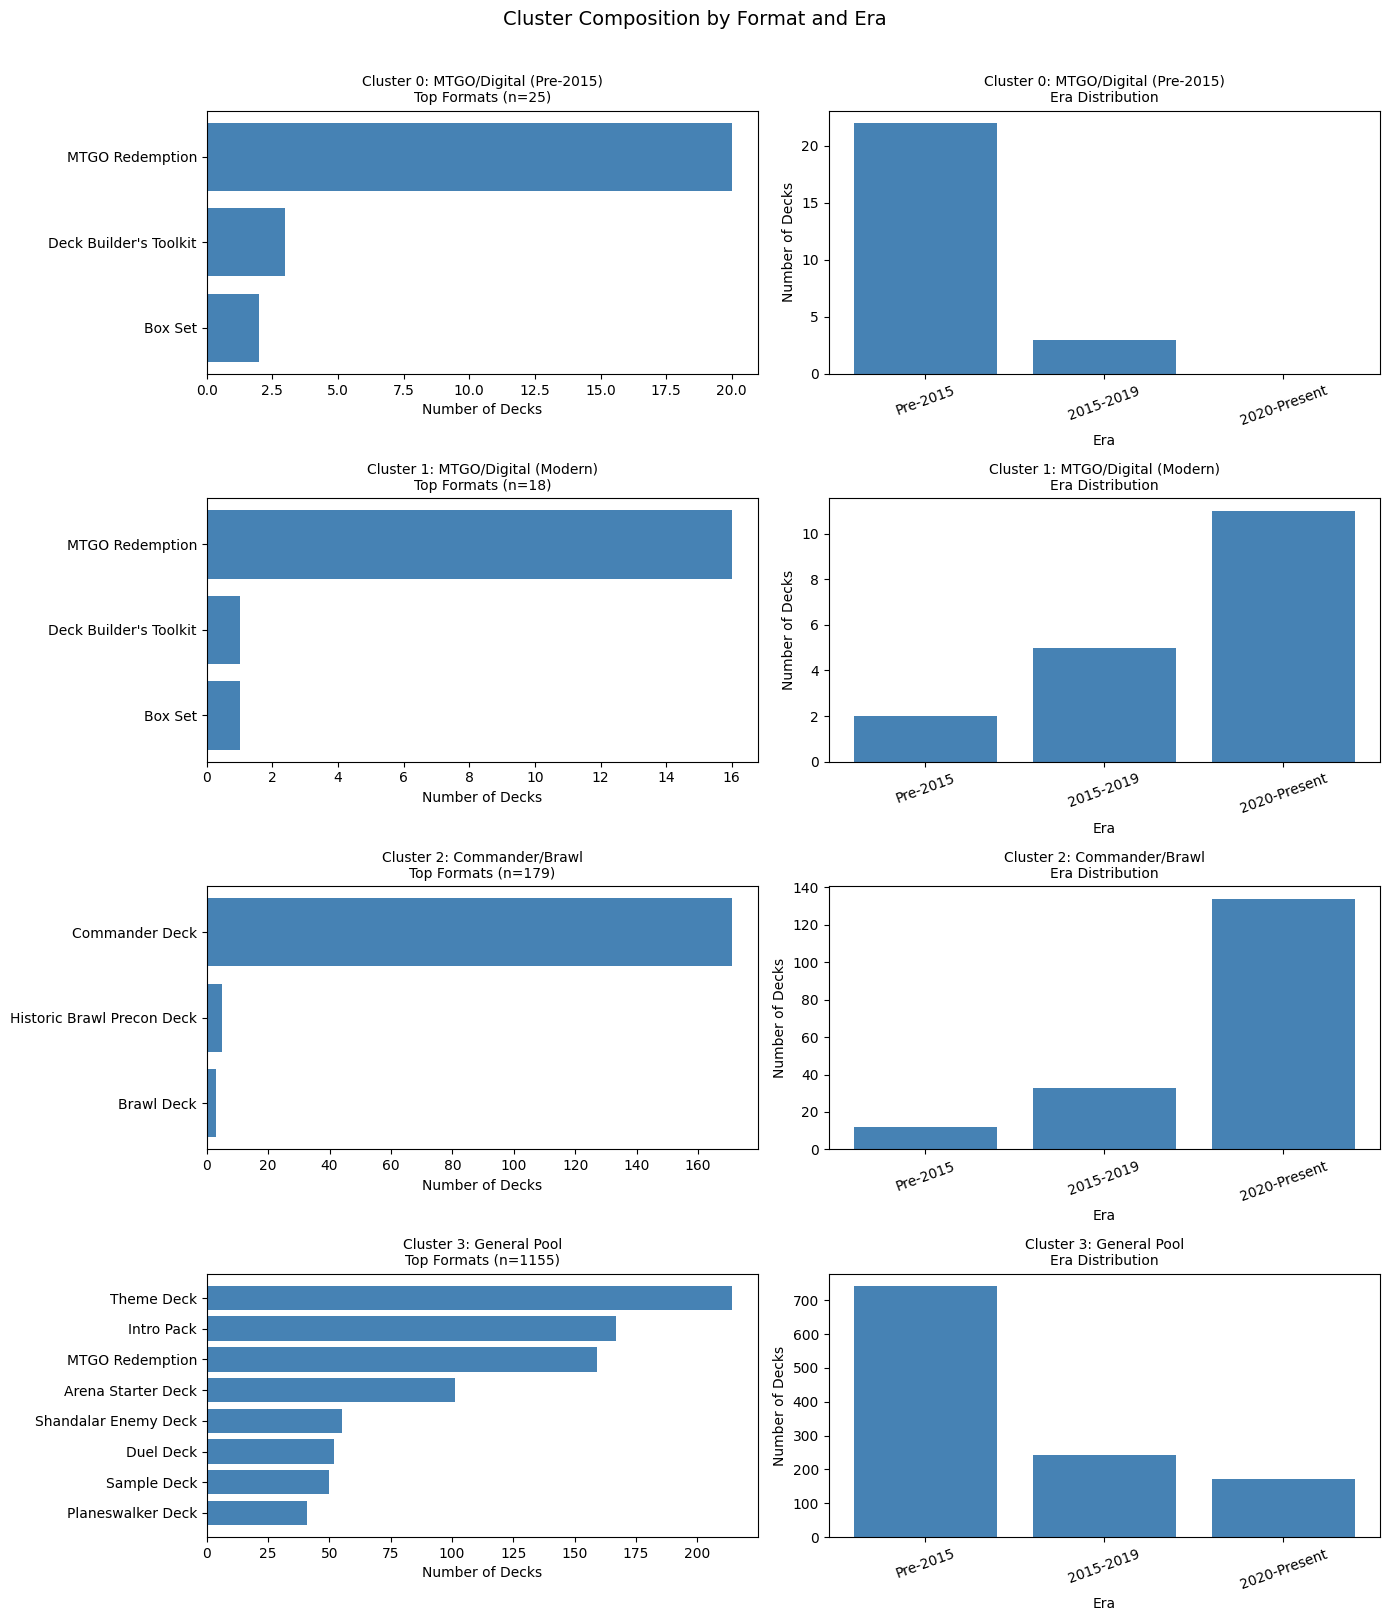

In [34]:
fig, axes = plt.subplots(K, 2, figsize=(14, K * 4))

cluster_names = {
    0: 'MTGO/Digital (Pre-2015)',
    1: 'MTGO/Digital (Modern)',
    2: 'Commander/Brawl',
    3: 'General Pool'
}
decks_df['cluster_label'] = decks_df['cluster'].map(cluster_names)
print('Cluster labels assigned:')
print(decks_df['cluster_label'].value_counts())


for k in range(K):
    subset = decks_df[decks_df['cluster'] == k]
    label = cluster_names[k]
    
    # Format breakdown
    fmt_counts = subset['deck_type'].value_counts().head(8)
    axes[k, 0].barh(fmt_counts.index[::-1], fmt_counts.values[::-1], color='steelblue')
    axes[k, 0].set_title(f'Cluster {k}: {label}\nTop Formats (n={len(subset)})', fontsize=10)
    axes[k, 0].set_xlabel('Number of Decks')

    # Era breakdown
    era_counts = subset['era'].value_counts().reindex(ERA_ORDER, fill_value=0)
    axes[k, 1].bar(era_counts.index, era_counts.values, color='steelblue')
    axes[k, 1].set_title(f'Cluster {k}: {label}\nEra Distribution', fontsize=10)
    axes[k, 1].set_xlabel('Era')
    axes[k, 1].set_ylabel('Number of Decks')
    axes[k, 1].tick_params(axis='x', rotation=20)

plt.suptitle('Cluster Composition by Format and Era', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs\\m3_cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 9.5: Interpreting Scatter Plot from K-Means
From the scatter plot we can see that deck structure is seperated primarily by the format of the deck, with commander and digital formats being the ones with enough variance to split off from the general pool. We also see that the digital cards from the later eras are much closer to the general pool than those from Pre-2015 suggesting that the format was once radically different but became more standard over time. 

We can also see that most of the commander decks were made post 2020. This makes sense as Wizards of The Coast swapped to releasing precons with each new expansion rather than once year. We also see that in the opposite fassion off the digital formats, commander tends to seems to get more different from the general pool the later it is released. Based on the commander x era results we got in Step 8.2 that showed supported cards tend to become more supported overtime within commander we could infer that this seperation from th general pool overtime is the result of change in the General Pool over time rather than in Commander. 

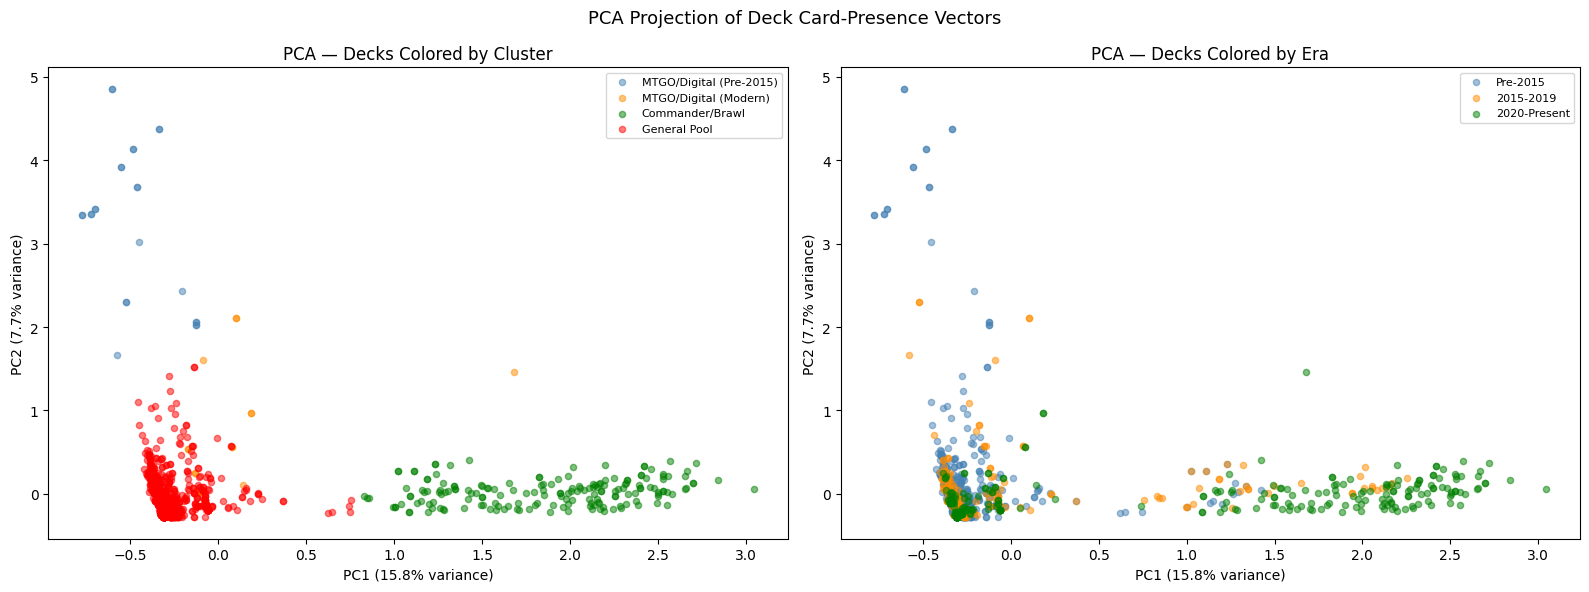

In [35]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(te_df_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_palette = {
    'MTGO/Digital (Pre-2015)': 'steelblue',
    'MTGO/Digital (Modern)':   'darkorange',
    'Commander/Brawl':         'green',
    'General Pool':            'red'
}

# Plot 1 — colored by cluster label
for label, color in cluster_palette.items():
    mask = decks_df['cluster_label'] == label
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    color=color, alpha=0.5, s=20, label=label)
axes[0].set_title('PCA — Decks Colored by Cluster', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend(fontsize=8)

# Plot 2 — colored by era
era_palette = {
    'Pre-2015':     'steelblue',
    '2015-2019':    'darkorange',
    '2020-Present': 'green'
}
for era, color in era_palette.items():
    mask = decks_df['era'] == era
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    color=color, alpha=0.5, s=20, label=era)
axes[1].set_title('PCA — Decks Colored by Era', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend(fontsize=8)

plt.suptitle('PCA Projection of Deck Card-Presence Vectors', fontsize=13)
plt.tight_layout()
plt.savefig('outputs\\m3_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9.6: Export

In [36]:
# Cluster assignments per deck
decks_df[['deck_name', 'deck_type', 'releaseDate', 'era', 'color_identity', 
           'cluster', 'cluster_label']].to_csv('outputs\\cluster_assignments.csv', index=False)

# Decision tree feature importances
importances = dt.feature_importances_
feature_names = te_df_cluster.columns.tolist()
importance_df = (
    pandas.DataFrame({'card': feature_names, 'importance': importances})
    .query('importance > 0')
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
importance_df.to_csv('outputs\\decision_tree_importances.csv', index=False)

# PCA coordinates with cluster labels attached
pca_df = pandas.DataFrame(coords, columns=['pca_x', 'pca_y'])
pca_df['cluster_label'] = decks_df['cluster_label'].values
pca_df['deck_type'] = decks_df['deck_type'].values
pca_df['era'] = decks_df['era'].values
pca_df.to_csv('outputs\\pca_coordinates.csv', index=False)

print('Exported: cluster_assignments.csv, decision_tree_importances.csv, pca_coordinates.csv')

Exported: cluster_assignments.csv, decision_tree_importances.csv, pca_coordinates.csv


# Step 10: Conclusions

## Commander Focus
As evidence by the cards with the most support and DQ1, the incredibly high support specifically within the commander format in DQ2, and the discovery of *Command Tower* as the most discriminating card in DQ3, we see that commander has the strongest patterns within the data set. This is very good for analysis of patterns within commander but does tell us that, based on the low support in the non commander formats overall, we can't draw nearly as sound conclussions outside of the commander format.

## Strong Color Based Staples
Although likely heavily biased towards commander, we did identify several color-based staples.

Mono-Color:
- Mono-White: *Pacifism* (31%) and *Serra Angel* (31%)
- Mono-Black: *Gravedigger* (22%)
- Mono-Red: *Shock* (39%)
- Mono-Green: *Giant Growth* (15%), *Llanowar Elves* (15%) and *Rampant Growth* (17%)

Two-Color:
- Azorius (WU): *Disenchant* (21%)
- Dimir (UB): *Gravedigger* (22%)
- Rakdos (BR): *Gravedigger* (22%)
- Gruul (RG): *Giant Growth* (34%)
- Selesnya (GW): *Llanowar Elves* (31%)
- Izzet (UR): *Unsummon* (33%)
- Boros (RW): *Serra Angel* (31%) and *Pacifism* (31%)
- Simic (GU): *Rampant Growth* (26%)
- Orzhov (WB): *Pacifism* (17%) and *Swords to Plowshares* (17%)

Three-Color:
- Naya (RGW): *Swords to Plowshares* (50%)
- Abzan (BGW): *Swords to Plowshares* (50%)
- Sultai (GUB): *Gravedigger* (27%)

Additionally *Swords to Plowshares* appears as the highest supported card in every white containing three-color combination, but is suprisingly absent from mono-white.

## Changes Over Time
The two most notable changes over time are:
1. Digital formats become more similar to the general pool with the lastest decks being almost absorbed by the generel pool. 
2. Commander staples show increasing support over time, suggesting either that the commander card pool became more consistent, or that commander decks appeared more frequently while maintaining a similar construction pattern. Either way, the widening gap between commander and non-commander clusters over time appears to be driven by changes in the broader card pool rather than changes within Commander itself.

## Red as a Descriminator
From on the decision tree from DQ3, we can see that dual lands serve as a descriminator for both commander and digital formats. The comman aspect between those dual lands is the pressence of red. This could mean that the presence of the color red serves as a descriminator for deck constitution.
